# Alert escalation: which alerts end up escalated?

**How to run.** Put the competition files under `data/` (`training/`, `test/`, `sample_submission.csv`) or point the `DATA_DIR` environment variable at them, install `requirements.txt` (or `uv sync`) and Restart & Run All. Paths are resolved from the notebook's location and seeds are fixed, so a clean run reproduces every figure, artifact and the submission file. For the judges: the whole notebook runs on a laptop CPU in a few minutes and needs no network access.

## Setup

### Imports, seed, versions

In [1]:
import hashlib
import json
import os
import platform
import random
from pathlib import Path

import catboost
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from scipy.stats import chi2_contingency, spearmanr
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

{"python": platform.python_version(), "pandas": pd.__version__, "numpy": np.__version__, "sklearn": sklearn.__version__, "lightgbm": lgb.__version__, "catboost": catboost.__version__}

{'python': '3.13.15',
 'pandas': '3.0.6',
 'numpy': '2.5.3',
 'sklearn': '1.9.1',
 'lightgbm': '4.7.0',
 'catboost': '1.2.10'}

### Paths

In [2]:
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = Path(os.environ.get("DATA_DIR", ROOT / "data"))
FIG_DIR, ART_DIR, SUB_DIR = ROOT / "figures", ROOT / "artifacts", ROOT / "submissions"
for d in (FIG_DIR, ART_DIR, SUB_DIR):
    d.mkdir(exist_ok=True)

FILES = {
    "train_signals": DATA_DIR / "training" / "train_signals.csv",
    "train_tx": DATA_DIR / "training" / "train_transactions.parquet",
    "test_signals": DATA_DIR / "test" / "test_signals.csv",
    "test_tx": DATA_DIR / "test" / "test_transactions.parquet",
    "sample_submission": DATA_DIR / "sample_submission.csv",
}
missing = [str(p) for p in FILES.values() if not p.exists()]
assert not missing, f"missing data files: {missing}"
ROOT, DATA_DIR

(PosixPath('/home/khaled/projects/automated-alerts'),
 PosixPath('/home/khaled/projects/automated-alerts/data'))

### Loaders

In [3]:
DATE_FMT = "%Y-%m-%d"
CAT_COLS = ["kirim_chiqim", "tranzaksiya_turi"]
TARGET = "eskalatsiya"


def load_signals(path):
    df = pd.read_csv(path)
    df["signal_sanasi"] = pd.to_datetime(df["signal_sanasi"], format=DATE_FMT)
    return df


def load_tx(path):
    tx = pd.read_parquet(path)
    assert tx["tranzaksiya_vaqti"].dt.tz is None
    for c in CAT_COLS:
        tx[c] = tx[c].astype("category")
    return tx

### Figure and insight helpers

In [4]:
INSIGHTS = []


def save_fig(fig, fig_id, finding, action=""):
    fig.savefig(FIG_DIR / f"{fig_id}.png", dpi=160, bbox_inches="tight")
    INSIGHTS.append({"figure": fig_id, "finding": finding, "action": action})
    plt.show()

## Load

Signals are one row per alert, transactions are many rows per alert. Everything downstream is left-joined onto the signal tables, so an alert without any history would still get a prediction.

In [5]:
tr_sig = load_signals(FILES["train_signals"])
te_sig = load_signals(FILES["test_signals"])
tr_tx = load_tx(FILES["train_tx"])
te_tx = load_tx(FILES["test_tx"])
sample = pd.read_csv(FILES["sample_submission"])
y = tr_sig[TARGET].to_numpy()

tr_sig.shape, tr_tx.shape, te_sig.shape, te_tx.shape, sample.shape

((14000, 3), (6987663, 5), (6000, 2), (3027575, 5), (6000, 2))

In [6]:
tr_sig.head(3)

,signal_id,signal_sanasi,eskalatsiya
0,SG_000002,2026-08-02,0
1,SG_000003,2025-12-15,0
2,SG_000004,2026-02-13,0


In [7]:
tr_tx.head(3)

,signal_id,tranzaksiya_vaqti,kirim_chiqim,tranzaksiya_turi,miqdor_indeksi
0,SG_016527,2024-07-06 08:47:18,chiqim,bank_otkazmasi,0.236245
1,SG_016527,2024-07-07 02:13:02,chiqim,bank_otkazmasi,1.130377
2,SG_016527,2024-07-08 11:15:12,kirim,karta,0.466360


In [8]:
sample.head(3)

,signal_id,ehtimollik
0,SG_000001,0.5
1,SG_000007,0.5
2,SG_000009,0.5


## Data audit

Before any modeling: is the data what the brief says, and how was the test set cut? With a single submission and no leaderboard, local validation has to mirror that split, so the audit also looks for anything that could leak into it (IDs, file order, alerts sharing a customer).

### Schema and grain

In [9]:
assert tr_sig["signal_id"].is_unique and te_sig["signal_id"].is_unique
assert list(sample.columns) == ["signal_id", "ehtimollik"]

schema = pd.DataFrame(
    [
        ("signals", "signal_id", "key", "alert id, one row per alert", tr_sig["signal_id"].dtype),
        ("signals", "signal_sanasi", "date", "alert date", tr_sig["signal_sanasi"].dtype),
        ("signals", "eskalatsiya", "target", "1 = escalated, 0 = dismissed (train only)", tr_sig[TARGET].dtype),
        ("transactions", "signal_id", "foreign key", "alert the transaction belongs to", tr_tx["signal_id"].dtype),
        ("transactions", "tranzaksiya_vaqti", "timestamp", "transaction time, naive, second precision", tr_tx["tranzaksiya_vaqti"].dtype),
        ("transactions", "kirim_chiqim", "category", "kirim = incoming, chiqim = outgoing", tr_tx["kirim_chiqim"].dtype),
        ("transactions", "tranzaksiya_turi", "category", "karta = card, bank_otkazmasi = transfer, naqd = cash, xalqaro = international", tr_tx["tranzaksiya_turi"].dtype),
        ("transactions", "miqdor_indeksi", "metric", "standardized transaction-size index", tr_tx["miqdor_indeksi"].dtype),
    ],
    columns=["table", "column", "role", "meaning", "dtype"],
)
schema

,table,column,role,meaning,dtype
0,signals,signal_id,key,"alert id, one row per alert",str
1,signals,signal_sanasi,date,alert date,datetime64[us]
2,signals,eskalatsiya,target,"1 = escalated, 0 = dismissed (train only)",int64
3,transactions,signal_id,foreign key,alert the transaction belongs to,str
4,transactions,tranzaksiya_vaqti,timestamp,"transaction time, naive, second precision",datetime64[us]
5,transactions,kirim_chiqim,category,"kirim = incoming, chiqim = outgoing",category
6,transactions,tranzaksiya_turi,category,"karta = card, bank_otkazmasi = transfer, naqd ...",category
7,transactions,miqdor_indeksi,metric,standardized transaction-size index,float64


### Integrity: keys, links, nulls, duplicates

In [10]:
def audit(sig, tx):
    ts = tx["tranzaksiya_vaqti"]
    sig_ids, tx_ids = set(sig["signal_id"]), set(tx["signal_id"])
    per_sig = tx.groupby("signal_id").size()
    return pd.Series(
        {
            "signals": len(sig),
            "duplicate_signal_ids": int(sig["signal_id"].duplicated().sum()),
            "distinct_alert_dates": sig["signal_sanasi"].nunique(),
            "signal_date_min": sig["signal_sanasi"].min().date(),
            "signal_date_max": sig["signal_sanasi"].max().date(),
            "tx_rows": len(tx),
            "exact_duplicate_tx_rows": int(tx.duplicated().sum()),
            "same_second_tx_pairs": int(tx.duplicated(["signal_id", "tranzaksiya_vaqti"]).sum()),
            "signals_without_tx": len(sig_ids - tx_ids),
            "orphan_tx_signal_ids": len(tx_ids - sig_ids),
            "null_cells_signals": int(sig.isna().sum().sum()),
            "null_cells_tx": int(tx.isna().sum().sum()),
            "nonfinite_amounts": int((~np.isfinite(tx["miqdor_indeksi"])).sum()),
            "tx_per_signal_min": int(per_sig.min()),
            "tx_per_signal_median": float(per_sig.median()),
            "tx_per_signal_p99": round(float(per_sig.quantile(0.99)), 1),
            "tx_per_signal_max": int(per_sig.max()),
            "tx_time_min": ts.min(),
            "tx_time_max": ts.max(),
            "share_tx_at_midnight": round(float((ts == ts.dt.normalize()).mean()), 5),
            "memory_mb_tx": round(tx.memory_usage(deep=True).sum() / 2**20),
        }
    )


overview = pd.concat([audit(tr_sig, tr_tx).rename("train"), audit(te_sig, te_tx).rename("test")], axis=1)
overview

,train,test
signals,14000,6000
duplicate_signal_ids,0,0
distinct_alert_dates,730,728
signal_date_min,2025-01-01,2025-01-01
signal_date_max,2026-12-31,2026-12-31
tx_rows,6987663,3027575
exact_duplicate_tx_rows,0,0
same_second_tx_pairs,93749,38650
signals_without_tx,0,0
orphan_tx_signal_ids,0,0


In [11]:
pd.Series(
    {
        "train/test signal_id overlap": len(set(tr_sig["signal_id"]) & set(te_sig["signal_id"])),
        "sample_submission ids == test ids, same order": sample["signal_id"].equals(te_sig["signal_id"]),
        "escalated alerts": int(tr_sig[TARGET].sum()),
        "escalation rate": round(tr_sig[TARGET].mean(), 4),
    }
)

train/test signal_id overlap                          0
sample_submission ids == test ids, same order      True
escalated alerts                                   2405
escalation rate                                  0.1718
dtype: object

Clean on every count: no nulls, duplicates, orphans(transaction without `signal_ids`) or alerts without history in either set, and the sample submission lists exactly the test IDs in the same order. Both sets cover the same two years (730 alert days), transactions start exactly 180 days before the first alert date and never run past the last one, and history sizes match (median 461 vs 460 per alert).

**To be used**

1. The symmetry between train and test points to a random split of alerts, not a time split. Validation should therefore be a stratified split of alerts rather than a time holdout.
2. There are no exact duplicate rows, but 1.3% of rows share a second with another row of the same alert. The relative-time section shows they sit almost entirely inside the pre-alert cluster (17% of its rows vs 0.04% elsewhere), so they are real burst activity and stay in.

Symmetry here means train and test look alike on everything measured: the same alert-date range, the same 180-day transaction window, the same history sizes, and the same category and amount distributions. Had the test set been a later period, its dates would sit after train's and its transaction window would start later. Instead the test alerts are spread through the same two years, so random folds of train face the same task the model will face on test, and a stratified split of alerts estimates the hidden score without any time-based correction.

### Categories, train vs test

In [12]:
pd.concat(
    [
        pd.concat([tr_tx[c].value_counts(normalize=True).rename("train"), te_tx[c].value_counts(normalize=True).rename("test")], axis=1)
        for c in CAT_COLS
    ],
    keys=CAT_COLS,
).round(4)

train    test
kirim_chiqim     kirim           0.7566  0.7553
                 chiqim          0.2434  0.2447
tranzaksiya_turi karta           0.5379  0.5367
                 bank_otkazmasi  0.3942  0.3955
                 naqd            0.0633  0.0633
                 xalqaro         0.0046  0.0045

In [13]:
pd.crosstab(tr_tx["kirim_chiqim"], tr_tx["tranzaksiya_turi"], normalize=True).round(4)

tranzaksiya_turi,bank_otkazmasi,karta,naqd,xalqaro
kirim_chiqim,,,,
chiqim,0.1015,0.1254,0.0155,0.0011
kirim,0.2927,0.4126,0.0478,0.0035


Identical value sets and shares that agree within 0.2 percentage points, so no mapping or cleaning is needed. Three in four transactions are incoming, card and bank transfer make up 93% of rows, cash 6% and international under 0.5%. International activity will be sparse per alert, so its features have to be counts and flags rather than distributions.

### Timestamps: hour of day and weekday

If the timestamps carry a daily rhythm, night-time activity and the timezone would matter; if they were date-only, hour features would be meaningless.

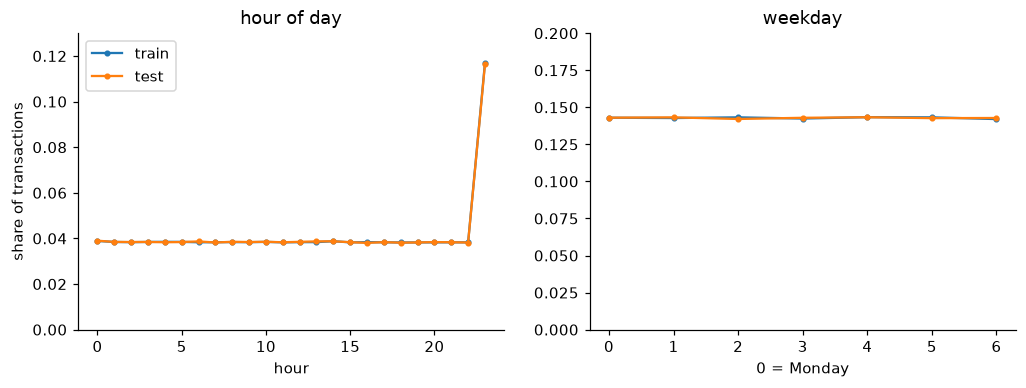

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for name, tx in [("train", tr_tx), ("test", te_tx)]:
    ts = tx["tranzaksiya_vaqti"]
    ts.dt.hour.value_counts(normalize=True).sort_index().plot(ax=axes[0], marker="o", ms=3, label=name)
    ts.dt.weekday.value_counts(normalize=True).sort_index().plot(ax=axes[1], marker="o", ms=3, label=name)
axes[0].set(title="hour of day", xlabel="hour", ylabel="share of transactions", ylim=(0, 0.13))
axes[1].set(title="weekday", xlabel="0 = Monday", ylim=(0, 0.2))
axes[0].legend()
save_fig(
    fig,
    "F00a_hour_weekday",
    "Hours 0-22 and all weekdays are flat (about 3.8% and 14.3% each); hour 23 alone holds 11.7% of transactions. No daytime pattern exists, so the timezone cannot be inferred and does not matter.",
    "No hour-of-day or weekday features; measure time relative to the alert date instead.",
)

Hours 0 to 22 and all seven weekdays sit at the uniform level (3.8% per hour, 14.3% per weekday). There is no daily or weekly rhythm to exploit, the timezone cannot be inferred and does not matter, and hour or weekday features would be noise. The one exception is hour 23 with three times the mass of any other hour. That is not a night-time habit: the next section shows it is a cluster of transactions sitting right before the alert date.

### Relative time: lookback window and the pre-alert cluster

Alerts fire on recent behaviour and analysts judge it against the customer's normal, so time only makes sense relative to the alert date. `lag_days` is alert date minus transaction day (0 = the alert day, 1 = the day before, negative = after the alert). Three questions: how long is the lookback, is anything recorded after the alert, and where does the hour-23 mass sit?

In [15]:
def add_rel_time(tx, sig):
    m = tx.merge(sig[["signal_id", "signal_sanasi"]], on="signal_id", how="left", validate="many_to_one")
    m["lag_days"] = (m["signal_sanasi"] - m["tranzaksiya_vaqti"].dt.normalize()).dt.days
    m["secs_before"] = (m["signal_sanasi"] - m["tranzaksiya_vaqti"]).dt.total_seconds()
    return m


def rel_time_stats(m):
    first_lag = m.groupby("signal_id")["lag_days"].max()
    last_hour = m["secs_before"].between(0, 3600)
    same_second = m.duplicated(["signal_id", "tranzaksiya_vaqti"])
    return pd.Series(
        {
            "lag_days_min": int(m["lag_days"].min()),
            "lag_days_max": int(m["lag_days"].max()),
            "lookback_days_median": float(first_lag.median()),
            "lookback_days_p05": float(first_lag.quantile(0.05)),
            "share_tx_after_alert_date": round(float((m["lag_days"] < 0).mean()), 5),
            "share_tx_on_alert_date": round(float((m["lag_days"] == 0).mean()), 5),
            "share_tx_day_before_alert": round(float((m["lag_days"] == 1).mean()), 4),
            "share_tx_last_hour_before_alert": round(float(last_hour.mean()), 4),
            "share_same_second_pairs_in_last_hour": round(float(same_second[last_hour].mean()), 4),
            "share_same_second_pairs_elsewhere": round(float(same_second[~last_hour].mean()), 5),
        }
    )


tr_m, te_m = add_rel_time(tr_tx, tr_sig), add_rel_time(te_tx, te_sig)
rel_time = pd.concat([rel_time_stats(tr_m).rename("train"), rel_time_stats(te_m).rename("test")], axis=1)
rel_time

,train,test
lag_days_min,0.00000,0.00000
lag_days_max,180.00000,180.00000
lookback_days_median,180.00000,180.00000
lookback_days_p05,170.00000,172.00000
share_tx_after_alert_date,0.00000,0.00000
share_tx_on_alert_date,0.00056,0.00048
share_tx_day_before_alert,0.08090,0.08000
share_tx_last_hour_before_alert,0.07900,0.07840
share_same_second_pairs_in_last_hour,0.16550,0.16130
share_same_second_pairs_elsewhere,0.00036,0.00012


Transactions are observed within a common 180-day lookback window (the earliest transaction sits 180 days out for the median alert and at least 170 days out for 95% of alerts), and nothing is recorded after the alert date in either set, so the question of whether to use post-alert transactions does not arise. Around 8% of all rows fall on the day before the alert, almost all of them within the last hour, and that hour also holds the same-second pairs (17% of its rows versus 0.04% elsewhere), so those are not data errors but part of a dense cluster.

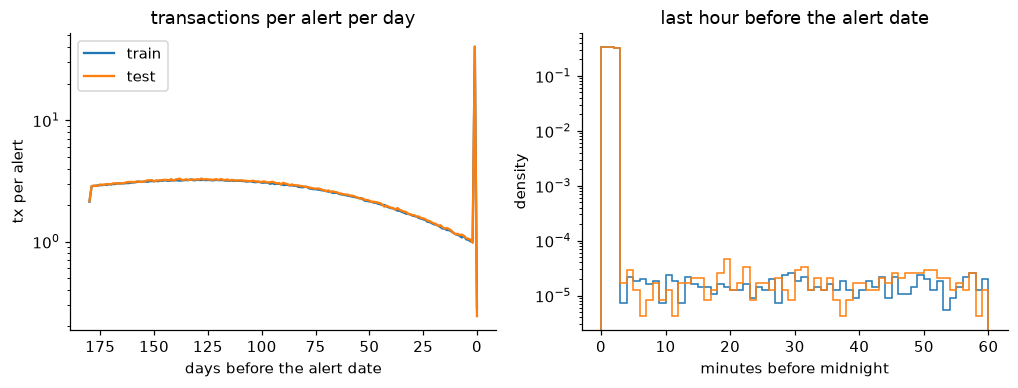

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for name, m, n in [("train", tr_m, len(tr_sig)), ("test", te_m, len(te_sig))]:
    (m["lag_days"].value_counts().sort_index() / n).plot(ax=axes[0], label=name)
    minutes = m.loc[m["secs_before"].between(0, 3600), "secs_before"] / 60
    axes[1].hist(minutes, bins=60, range=(0, 60), density=True, histtype="step", label=name)
axes[0].set(title="transactions per alert per day", xlabel="days before the alert date", ylabel="tx per alert", yscale="log")
axes[0].invert_xaxis()
axes[0].legend()
axes[1].set(title="last hour before the alert date", xlabel="minutes before midnight", ylabel="density", yscale="log")
save_fig(
    fig,
    "F00b_relative_time",
    "Transactions are observed within a common 180-day lookback window ending on the alert date, with nothing after it. About 8% of all transactions (median 31 per alert) sit in the last few minutes before the alert date starts; background activity is 1-3 per day and declines towards the alert. 152 alerts have no such cluster and 21 carry it late on the alert day itself.",
    "Treat the cluster (lag_days <= 1) as its own window; use 7/30/90/180-day windows for the background and recent-vs-baseline ratios.",
)

Left panel, read from left to right: background activity is a smooth hump. It rises from about 2 transactions per alert per day at 180 days out to a peak of about 3 around 120 days, then declines steadily to about 1 per day in the week before the alert, and then the last day jumps to about 40. Train and test lie on top of each other. The right panel zooms into that last hour: nearly everything sits in the last three minutes before midnight (median 1.5 minutes, 99% within 3), the rest of the hour is at the background level.

So an alert follows months of slowly falling activity and then a dense burst immediately before the alert date. The burst is the trigger; the preceding months are the customer's normal. Features should describe both, and the burst relative to each alert's own background is the main behavioural hypothesis to test.

In [17]:
last_hour = tr_m[tr_m["secs_before"].between(0, 3600)]
cluster_size = last_hour.groupby("signal_id").size().reindex(tr_sig["signal_id"], fill_value=0)
late = tr_m[tr_m["secs_before"] < 0]
print("alerts without a last-hour transaction:", int((cluster_size == 0).sum()))
print("rows after the alert midnight, same calendar day:", len(late), "in", late["signal_id"].nunique(), "alerts")

pct = [0.01, 0.1, 0.5, 0.9, 0.99]
pd.DataFrame(
    {
        "minutes_before_midnight": (last_hour["secs_before"] / 60).describe(percentiles=pct),
        "cluster_size_per_alert": cluster_size.describe(percentiles=pct),
    }
).round(1)

alerts without a last-hour transaction: 152
rows after the alert midnight, same calendar day: 840 in 21 alerts


,minutes_before_midnight,cluster_size_per_alert
count,552279.0,14000.0
mean,1.5,39.4
std,1.3,35.9
min,0.0,0.0
1%,0.0,0.0
10%,0.3,6.0
50%,1.5,31.0
90%,2.6,83.0
99%,2.9,158.0
max,60.0,786.0


152 alerts (1%) have no burst at all and 21 carry it late on the alert day itself (their rows fall after midnight, still on the alert date). The burst window is therefore defined by `lag_days <= 1`, not by a clock time. Its size varies a lot between alerts (10th to 90th percentile: 6 to 83 transactions), which makes the burst the first place to look for behavioural differences once the audit is done.

### Amount index forensics

`miqdor_indeksi` is a standardized size indicator with an unknown transform. Whether it is a global z-score, a per-alert z-score (which would erase absolute size), signed by direction, or log-scaled decides which aggregates are meaningful.

In [18]:
amt = tr_tx["miqdor_indeksi"]
centered = (amt - amt.mean()).abs()
pd.Series(
    {
        "mean": amt.mean(),
        "sd": amt.std(),
        "min": amt.min(),
        "max": amt.max(),
        "share_negative": (amt < 0).mean(),
        "skew": amt.skew(),
        "excess_kurtosis": amt.kurt(),
        "within_1sd": (centered < amt.std()).mean(),
        "within_2sd": (centered < 2 * amt.std()).mean(),
        "within_3sd": (centered < 3 * amt.std()).mean(),
    }
).round(4)

mean              -0.1334
sd                 0.9811
min               -2.9123
max                6.6917
share_negative     0.6032
skew               0.6328
excess_kurtosis    0.9806
within_1sd         0.7116
within_2sd         0.9515
within_3sd         0.9925
dtype: float64

In [19]:
qs = [0.001, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]
pd.DataFrame({"train": amt.quantile(qs), "test": te_tx["miqdor_indeksi"].quantile(qs)}).round(3).T

,0.001,0.010,0.050,0.250,0.500,0.750,0.950,0.990,0.999
train,-2.884,-2.118,-1.542,-0.799,-0.244,0.430,1.641,2.639,3.947
test,-2.886,-2.119,-1.541,-0.791,-0.233,0.446,1.663,2.670,3.972


Mean −0.13, sd 0.98 and 71 / 95 / 99% of values within 1 / 2 / 3 sd: this is essentially a Gaussian with a mild right tail (skew 0.63) and a hard floor at −2.91. Train and test quantiles agree to two decimals, so the amount scale is the same in both sets.

In [20]:
per_sig = tr_tx.groupby("signal_id")["miqdor_indeksi"].agg(["mean", "std", "count"])
per_sig.loc[per_sig["count"] >= 10, ["mean", "std"]].describe().round(3)

,mean,std
count,13834.000,13834.000
mean,-0.062,0.866
std,0.492,0.207
min,-1.739,0.287
25%,-0.399,0.713
50%,-0.084,0.851
75%,0.253,0.997
max,1.844,1.917


Per-alert means spread with sd 0.49 and per-alert sds range from 0.3 to 1.9, so the index is not standardized within each alert. Absolute size differences between alerts survive and per-alert sums and means are meaningful.

In [21]:
tr_tx.groupby(CAT_COLS)["miqdor_indeksi"].agg(["count", "mean", "std", "median", "min", "max"]).round(3)

count   mean    std  median    min    max
kirim_chiqim tranzaksiya_turi                                             
chiqim       bank_otkazmasi     709255  0.318  1.155   0.269 -2.839  6.692
             karta              875947 -0.076  0.841  -0.122 -2.269  4.183
             naqd               108125  0.785  0.868   0.751 -1.321  4.863
             xalqaro              7456  2.169  1.151   2.066 -0.578  6.430
kirim        bank_otkazmasi    2045432  0.077  1.116   0.040 -2.912  6.692
             karta             2882850 -0.537  0.658  -0.574 -2.227  4.183
             naqd               334221  0.452  0.756   0.397 -1.257  4.563
             xalqaro             24377  1.934  1.043   1.796 -0.355  6.430

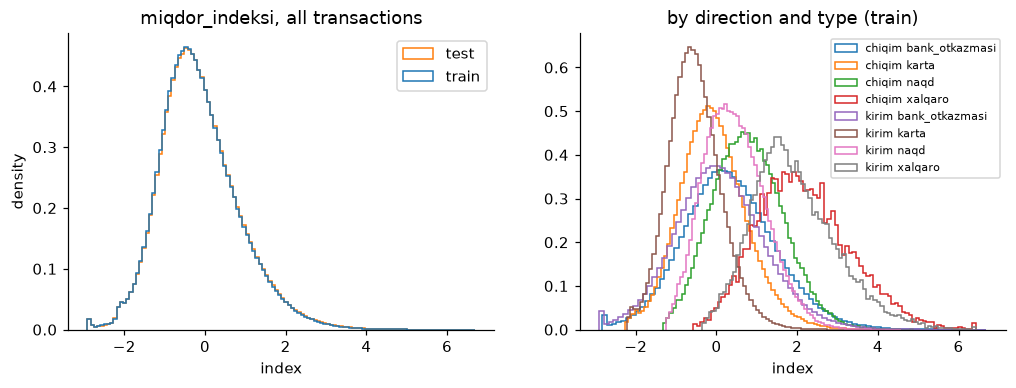

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist([amt, te_tx["miqdor_indeksi"]], bins=120, density=True, histtype="step", label=["train", "test"])
axes[0].set(title="miqdor_indeksi, all transactions", xlabel="index", ylabel="density")
axes[0].legend()
for (direction, tx_type), s in tr_tx.groupby(CAT_COLS)["miqdor_indeksi"]:
    axes[1].hist(s, bins=80, density=True, histtype="step", label=f"{direction} {tx_type}")
axes[1].set(title="by direction and type (train)", xlabel="index")
axes[1].legend(fontsize=7)
save_fig(
    fig,
    "F00c_amount_index",
    "The index is one common scale for all transactions (not standardized per alert): near-normal with a right tail, a hard floor near -2.9, mean shifting by type (card lowest, international highest) and outgoing above incoming. Only four exact values repeat, and each is the maximum of one transaction type, so amounts are capped per type; the 120 alerts that hit a cap escalate at 13% vs 17% overall, within noise.",
    "Use the index as is (plus exp for money-like sums); build shares and counts above thresholds by type and direction; try a hit-the-cap flag.",
)

Every direction × type cell is itself a bell curve on the same scale, only shifted: card is lowest, then bank transfer, cash, and international about two sd higher, with outgoing above incoming in every channel. The overall skew is just the mixture of these shifted normals. A near-normal index whose mean moves with the payment channel is what a z-scored log-amount looks like, so `exp(index)` behaves like money and its sums are meaningful, while the raw index is fine for thresholds and shares.

Because the distributions are Gaussian per channel, a value two sd above its channel mean is unusual in the same sense for a card payment and for a cash deposit. That motivates channel-relative amount features (how far an alert's cash or international transactions sit from the channel norm, how many exceed the channel's 95th percentile) rather than one global threshold, which would mostly flag international transfers.

In [23]:
value_counts = amt.value_counts()
repeated = value_counts[value_counts > 1]
rep_rows = tr_tx[tr_tx["miqdor_indeksi"].isin(repeated.index)]
has_rep = tr_sig["signal_id"].isin(rep_rows["signal_id"])
print("values repeated exactly:", len(repeated), "| rows:", int(repeated.sum()), "| rows in test:", int(te_tx["miqdor_indeksi"].isin(repeated.index).sum()))
print("alerts with a repeated amount:", int(has_rep.sum()), "| their escalation rate:", round(tr_sig.loc[has_rep, TARGET].mean(), 3))
pd.crosstab(rep_rows["miqdor_indeksi"], [rep_rows["kirim_chiqim"], rep_rows["tranzaksiya_turi"]])

values repeated exactly: 4 | rows: 145 | rows in test: 85
alerts with a repeated amount: 120 | their escalation rate: 0.133


kirim_chiqim             chiqim                             kirim              
tranzaksiya_turi bank_otkazmasi karta naqd xalqaro bank_otkazmasi karta xalqaro
miqdor_indeksi                                                                 
4.183498                      0   114    0       0              0     1       0
4.862791                      0     0    6       0              0     0       0
6.430390                      0     0    0       7              0     0       6
6.691657                      6     0    0       0              5     0       0

Only four values repeat exactly among seven million rows, and each one is the maximum of a single transaction type (compare with the max column above): amounts are capped per channel and the repeats are transactions hitting the cap. No round-amount heaping survived the transform. Hitting a cap is rare (120 alerts) and shows no excess escalation (13% vs 17% overall), so at most it becomes a small flag to test later.

### ID and row-order artifacts

Synthetic data sometimes leaks the label through the way IDs were assigned or files were written. Anything found here is reported as a data-quality observation, never used as a feature.

In [24]:
id_num = tr_sig["signal_id"].str.slice(3).astype(int)
first_pos = tr_tx.reset_index().groupby("signal_id")["index"].first().reindex(tr_sig["signal_id"]).to_numpy()
alert_date = tr_sig["signal_sanasi"].astype("int64")

pd.Series(
    {
        "AUC id number": roc_auc_score(y, id_num),
        "AUC signal file row order": roc_auc_score(y, np.arange(len(y))),
        "AUC first position in the transaction file": roc_auc_score(y, first_pos),
        "AUC alert date": roc_auc_score(y, alert_date),
        "spearman(id, alert date)": id_num.corr(alert_date, method="spearman"),
    }
).round(4)

AUC id number                                 0.4985
AUC signal file row order                     0.4985
AUC first position in the transaction file    0.5078
AUC alert date                                0.5076
spearman(id, alert date)                     -0.0009
dtype: float64

In [25]:
all_ids = pd.concat([tr_sig["signal_id"], te_sig["signal_id"]]).str.slice(3).astype(int).to_numpy()
is_test = np.r_[np.zeros(len(tr_sig)), np.ones(len(te_sig))]
pd.Series(is_test).groupby(pd.qcut(all_ids, 10, labels=False)).mean().round(3).rename("test share by id decile")

0    0.298
1    0.290
2    0.322
3    0.300
4    0.282
5    0.302
6    0.294
7    0.297
8    0.299
9    0.315
Name: test share by id decile, dtype: float64

Nothing leaks: the ID number, both file orders and the alert date all score 0.50 to 0.51 against the target, and the ID is unrelated to the date. IDs run from 1 to 20000 with a 30% test share in every decile, so the test set is a random 30% sample of alerts, not a later period. That is the split the validation scheme has to mirror.

### Shared histories across alerts

One customer can trigger several alerts. If two alerts share identical transaction rows they belong to the same customer, which would call for group-aware validation and prior-alert features.

In [26]:
tx_all = pd.concat([tr_tx, te_tx], ignore_index=True)
row_hash = pd.util.hash_pandas_object(tx_all[["tranzaksiya_vaqti", "kirim_chiqim", "tranzaksiya_turi", "miqdor_indeksi"]], index=False)
row_alert = pd.DataFrame({"row_hash": row_hash.to_numpy(), "signal_id": tx_all["signal_id"].to_numpy()}).drop_duplicates()
shared = row_alert[row_alert.duplicated("row_hash", keep=False)]
del tx_all, row_hash

pd.Series(
    {
        "transaction rows, train + test": len(row_alert),
        "distinct rows": row_alert["row_hash"].nunique(),
        "rows under more than one alert": shared["row_hash"].nunique(),
        "alerts involved": shared["signal_id"].nunique(),
    }
)

transaction rows, train + test    10015238
distinct rows                     10015238
rows under more than one alert           0
alerts involved                          0
dtype: int64

Not a single row appears under two alerts, in train, in test or across them. Every alert is an independent history, so there are no pseudo-customers to group folds by and no prior-alert history to exploit. Plain stratified K-fold is safe.

### Dataset overview table and exports

The overview table, the schema and the figure findings go to the EDA website as its dataset section.

In [27]:
overview = pd.concat([overview, rel_time])
overview.loc["escalation_rate"] = [round(tr_sig[TARGET].mean(), 4), None]
overview.to_csv(ART_DIR / "F00_dataset_overview.csv")
schema.to_csv(ART_DIR / "F00_schema.csv", index=False)
overview

,train,test
signals,14000,6000
duplicate_signal_ids,0,0
distinct_alert_dates,730,728
signal_date_min,2025-01-01,2025-01-01
signal_date_max,2026-12-31,2026-12-31
tx_rows,6987663,3027575
exact_duplicate_tx_rows,0,0
same_second_tx_pairs,93749,38650
signals_without_tx,0,0
orphan_tx_signal_ids,0,0


## Target, split and validation

The audit showed that the test set is a random 30% of alerts drawn from the same two years, and that every alert is an independent history. This section turns that into one fixed way of scoring every later choice. A fifth of the labeled alerts is set aside as a confirmation holdout that is scored once, after the model is frozen; every decision before that is made on five fixed folds of the remaining development set. The section ends with a baseline model and a valid submission file, so a legal CSV exists from here on.

### Target

How rare is escalation? The rate decides how many escalated alerts each fold gets and whether the split has to be stratified.

In [28]:
pd.Series(
    {
        "alerts": len(y),
        "escalated": int(y.sum()),
        "dismissed": int((y == 0).sum()),
        "escalation rate": round(y.mean(), 4),
        "dismissed per escalated": round((y == 0).sum() / y.sum(), 2),
    },
    dtype=object,
)

alerts                      14000
escalated                    2405
dismissed                   11595
escalation rate            0.1718
dismissed per escalated      4.82
dtype: object

2,405 of 14,000 alerts were escalated (17.2%), about one for every 4.8 dismissed. That is imbalanced but not rare. ROC-AUC only ranks alerts, so the metric itself needs no resampling or class weights, and 2,405 escalations are enough for five folds of about 385 each. The imbalance matters for the split: it is stratified, so every part keeps the same 17.2%.

### Development set, holdout and folds

The split is made before any view that uses labels, so the holdout never shapes a feature or a model choice. Everything is stratified on the target and seeded. `split.csv` records each alert's part, its development fold and its fold for the final fit on all 14,000 alerts.

In [29]:
dev_idx, hold_idx = train_test_split(np.arange(len(y)), test_size=0.2, stratify=y, random_state=SEED)
dev_idx, hold_idx = np.sort(dev_idx), np.sort(hold_idx)
y_dev = y[dev_idx]
dev_sig = tr_sig.iloc[dev_idx].reset_index(drop=True)

folds = list(StratifiedKFold(5, shuffle=True, random_state=SEED).split(np.zeros(len(y_dev)), y_dev))
final_folds = list(StratifiedKFold(5, shuffle=True, random_state=SEED).split(np.zeros(len(y)), y))

split = pd.DataFrame({"signal_id": tr_sig["signal_id"], "part": "holdout", "dev_fold": -1, "final_fold": -1})
split.loc[dev_idx, "part"] = "dev"
for k, (_, va) in enumerate(folds):
    split.loc[dev_idx[va], "dev_fold"] = k
for k, (_, va) in enumerate(final_folds):
    split.loc[va, "final_fold"] = k
split.to_csv(ART_DIR / "split.csv", index=False)
split.assign(y=y).groupby(["part", "dev_fold"])["y"].agg(alerts="size", escalated="sum", rate="mean").round(4)

alerts  escalated    rate
part    dev_fold                           
dev      0          2240        384  0.1714
         1          2240        385  0.1719
         2          2240        385  0.1719
         3          2240        385  0.1719
         4          2240        385  0.1719
holdout -1          2800        481  0.1718

Every part keeps the 17.18% rate: 11,200 development alerts in five folds of 2,240 (384 or 385 escalated each), and 2,800 holdout alerts with 481 escalated. From here on every view that uses labels runs on the development set only (`dev_sig`, `y_dev`). The holdout labels are not read again until the model is frozen.

### Escalation rate over time

The test alerts are spread over the same two years, so a change in escalation policy would not break the split, but it would make old alerts poor teachers for recent ones, and a clear trend would call for time-ordered validation. The monthly rate on the development set is shown with a 95% Wilson interval; months hold 266 to 688 development alerts, so each interval is 3 to 4.5 points on either side.

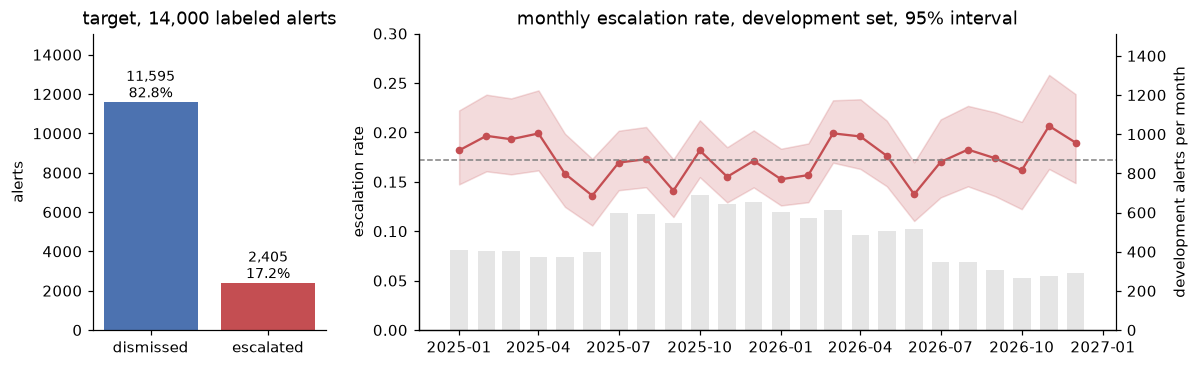

In [30]:
CLASS_COLORS = {0: "#4C72B0", 1: "#C44E52"}


def wilson(k, n, z=1.96):
    k, n = np.asarray(k, dtype=float), np.asarray(n, dtype=float)
    p = k / n
    d = 1 + z**2 / n
    c = (p + z**2 / (2 * n)) / d
    h = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / d
    return c - h, c + h


monthly = dev_sig.set_index("signal_sanasi").resample("MS")[TARGET].agg(["sum", "count"])
monthly["rate"] = monthly["sum"] / monthly["count"]
monthly["lo"], monthly["hi"] = wilson(monthly["sum"], monthly["count"])

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), gridspec_kw={"width_ratios": [1, 3]})
counts = np.bincount(y)
axes[0].bar(["dismissed", "escalated"], counts, color=[CLASS_COLORS[0], CLASS_COLORS[1]])
for i, c in enumerate(counts):
    axes[0].text(i, c, f"{c:,}\n{c / len(y):.1%}", ha="center", va="bottom", fontsize=9)
axes[0].set(title="target, 14,000 labeled alerts", ylabel="alerts", ylim=(0, counts.max() * 1.3))
volume = axes[1].twinx()
volume.bar(monthly.index, monthly["count"], width=20, color="grey", alpha=0.2)
volume.set(ylabel="development alerts per month", ylim=(0, monthly["count"].max() * 2.2))
volume.spines["right"].set_visible(True)
axes[1].set_zorder(volume.get_zorder() + 1)
axes[1].patch.set_visible(False)
axes[1].plot(monthly.index, monthly["rate"], marker="o", ms=4, color=CLASS_COLORS[1])
axes[1].fill_between(monthly.index, monthly["lo"], monthly["hi"], color=CLASS_COLORS[1], alpha=0.2)
axes[1].axhline(y_dev.mean(), ls="--", c="grey", lw=1)
axes[1].set(title="monthly escalation rate, development set, 95% interval", ylabel="escalation rate", ylim=(0, 0.3))
save_fig(
    fig,
    "F01_target_and_monthly_rate",
    "17.2% of labeled alerts are escalated (2,405 of 14,000, one for every 4.8 dismissed). On the development set the monthly rate stays between 13.6% and 20.7% with no step or trend (chi-square p = 0.14 over 24 months, 2025 at 17.0% vs 2026 at 17.3%), while monthly alert volume moves in steps (up by about 60% in July 2025, down in April and again in July 2026).",
    "Escalation policy is stable: keep stratified folds without time ordering, and no date or calendar features.",
)

In [31]:
by_month = dev_sig["signal_sanasi"].dt.to_period("M")
pd.Series(
    {
        "chi-square p, 24 months": chi2_contingency(pd.crosstab(by_month, y_dev))[1],
        "spearman, month order vs rate": spearmanr(np.arange(len(monthly)), monthly["rate"]).statistic,
        "share of monthly intervals missing the overall rate": ((monthly["lo"] > y_dev.mean()) | (monthly["hi"] < y_dev.mean())).mean(),
        "rate 2025": y_dev[by_month.dt.year == 2025].mean(),
        "rate 2026": y_dev[by_month.dt.year == 2026].mean(),
        "AUC alert date, dev": roc_auc_score(y_dev, dev_sig["signal_sanasi"].astype("int64")),
    }
).round(4)

chi-square p, 24 months                                0.1437
spearman, month order vs rate                          0.0478
share of monthly intervals missing the overall rate    0.0417
rate 2025                                              0.1704
rate 2026                                              0.1734
AUC alert date, dev                                    0.5008
dtype: float64

The rate moves between 13.6% and 20.7% from month to month but has no step and no trend. A chi-square test of the 24 months against one common rate gives p = 0.14, the rank correlation between month order and rate is 0.05, and only one of the 24 monthly intervals (4%) misses the overall 17.2%, less than the 5% a 95% interval allows by chance. 2025 and 2026 escalate at 17.0% and 17.3%. The escalation rule did not change over the two years, so time-ordered validation is not needed and the stratified folds stand.

The grey bars show a second thing: alert volume moves in steps, up by about 60% in July 2025, then down in April 2026 and again in July 2026 to under half its peak, yet the rate does not follow it. Whether more alerts on a day change how they are judged is the next check.

### Alerts per day

Analysts might escalate less on busy days, when the queue is long. The number of alerts raised on the same date (train and test together, no labels) is set against escalation on the development set. This is context about the alerting system, not an identifier of the date.

In [32]:
def rate_by_bin(x, y, q=10):
    x = pd.Series(np.asarray(x, dtype=float))
    g = (
        pd.DataFrame({"b": pd.qcut(x.rank(method="first"), q, labels=False), "x": x, "y": np.asarray(y)})
        .groupby("b")
        .agg(n=("y", "size"), k=("y", "sum"), x_med=("x", "median"))
    )
    g["rate"] = g["k"] / g["n"]
    g["lo"], g["hi"] = wilson(g["k"], g["n"])
    return g


per_day = pd.concat([tr_sig["signal_sanasi"], te_sig["signal_sanasi"]]).value_counts()
alerts_same_day = tr_sig["signal_sanasi"].map(per_day).to_numpy()
rate_by_bin(alerts_same_day[dev_idx], y_dev).round(3)

,n,k,x_med,rate,lo,hi
b,,,,,,
0,1120,204,16.0,0.182,0.161,0.206
1,1120,204,20.0,0.182,0.161,0.206
2,1120,185,24.0,0.165,0.145,0.188
3,1120,196,26.0,0.175,0.154,0.198
4,1120,195,29.0,0.174,0.153,0.197
5,1120,212,31.0,0.189,0.167,0.213
6,1120,169,35.0,0.151,0.131,0.173
7,1120,181,37.0,0.162,0.141,0.184
8,1120,187,41.0,0.167,0.146,0.190


In [33]:
pd.Series(
    {
        "alerts per day, min": per_day.min(),
        "median": per_day.median(),
        "max": per_day.max(),
        "AUC alerts per day, dev": round(roc_auc_score(y_dev, alerts_same_day[dev_idx]), 4),
    },
    dtype=object,
)

alerts per day, min             8
median                       27.0
max                            55
AUC alerts per day, dev    0.4899
dtype: object

Days range from 8 to 55 alerts (median 27). Alerts from the busiest tenth of days (median 45 a day) escalate at 17.1% against 18.2% for the quietest tenth (16 a day), the deciles move between 15.1% and 18.9% with no direction, every decile's interval contains the overall rate, and the AUC is 0.49. Workload does not change the outcome, so it is not worth a feature.

### Alert-date calendar

Alerts raised on a particular weekday, at month end or around a public holiday could be judged differently. The holidays checked are Navruz (21 March), Independence Day (1 September), Ramazon hayit (30 March 2025, 20 March 2026) and Qurbon hayit (6 June 2025, 27 May 2026), with three days on either side.

In [34]:
alert_day = dev_sig["signal_sanasi"]
HOLIDAYS = pd.to_datetime(["2025-03-21", "2026-03-21", "2025-09-01", "2026-09-01", "2025-03-30", "2026-03-20", "2025-06-06", "2026-05-27"])
calendar = {
    "weekday, 0 = Monday": alert_day.dt.weekday,
    "last 3 days of the month": alert_day.dt.days_in_month - alert_day.dt.day < 3,
    "within 3 days of a holiday": (np.abs(alert_day.to_numpy()[:, None] - HOLIDAYS.to_numpy()) <= np.timedelta64(3, "D")).any(axis=1),
}


def rate_by_group(key, y):
    g = pd.DataFrame({"key": np.asarray(key), "y": y}).groupby("key")["y"].agg(n="size", k="sum")
    g["rate"] = g["k"] / g["n"]
    g["lo"], g["hi"] = wilson(g["k"], g["n"])
    return g


pd.concat({name: rate_by_group(key, y_dev) for name, key in calendar.items()}).round(3)

n     k   rate     lo     hi
                           key                                  
weekday, 0 = Monday        0     1542   266  0.173  0.154  0.192
                           1     1600   250  0.156  0.139  0.175
                           2     1631   298  0.183  0.165  0.202
                           3     1611   277  0.172  0.154  0.191
                           4     1614   292  0.181  0.163  0.200
                           5     1544   253  0.164  0.146  0.183
                           6     1658   288  0.174  0.156  0.193
last 3 days of the month   0    10098  1741  0.172  0.165  0.180
                           1     1102   183  0.166  0.145  0.189
within 3 days of a holiday 0    10465  1791  0.171  0.164  0.178
                           1      735   133  0.181  0.155  0.210

In [35]:
pd.Series({name: chi2_contingency(pd.crosstab(np.asarray(key), y_dev))[1] for name, key in calendar.items()}).round(3).rename("chi-square p")

weekday, 0 = Monday           0.451
last 3 days of the month      0.625
within 3 days of a holiday    0.528
Name: chi-square p, dtype: float64

Nothing on the calendar moves the rate. Weekdays range from 15.6% to 18.3% (p = 0.45), the last three days of a month escalate at 16.6% against 17.2% for the rest (p = 0.63), and alerts within three days of a holiday at 18.1% against 17.1% (p = 0.53). Together with the flat monthly rate this rules out date-based features: when an alert was raised says nothing about how it ends.

### Baseline features: full-history totals

The baseline uses the simplest summary of each history: count, sum, mean, spread and maximum of the amount index over the whole 180-day lookback window, plus count, sum and maximum for each of the eight direction × type channels, 29 columns in all. The burst before the alert and the background are deliberately not separated. The baseline is a reference point, the input for adversarial validation and the source of a first valid submission. Counts and sums are 0 for a channel an alert never used, while its maximum stays missing, because never using a channel is not the same as using it for small amounts.

In [36]:
VAL = "miqdor_indeksi"
DIR_TYPES = [f"{d}_{t}" for d in ("chiqim", "kirim") for t in ("bank_otkazmasi", "karta", "naqd", "xalqaro")]


def history_totals(tx, sig):
    g = tx.groupby("signal_id")[VAL]
    total = pd.DataFrame(
        {"all_count": g.size(), "all_sum_amount": g.sum(), "all_mean_amount": g.mean(), "all_amount_std": g.std(), "all_max_amount": g.max()}
    )
    dir_type = pd.Categorical(tx["kirim_chiqim"].astype(str) + "_" + tx["tranzaksiya_turi"].astype(str), categories=DIR_TYPES)
    by_channel = tx.groupby(["signal_id", dir_type], observed=False)[VAL].agg(count="size", sum="sum", max="max").unstack()
    by_channel.columns = [f"all_{t}_{a}" for a, t in by_channel.columns]
    X = pd.concat([total, by_channel], axis=1).reindex(sig["signal_id"]).reset_index(drop=True)
    zero = X.columns[X.columns.str.endswith(("_count", "_sum"))]
    X[zero] = X[zero].fillna(0)
    return X


X0_tr, X0_te = history_totals(tr_tx, tr_sig), history_totals(te_tx, te_sig)
assert list(X0_te.columns) == list(X0_tr.columns)
assert (X0_tr.filter(regex="_count$").drop(columns="all_count").sum(axis=1) == X0_tr["all_count"]).all()
X0_tr.shape, X0_te.shape

((14000, 29), (6000, 29))

### Does the test set look like train?

The audit found a 30% test share in every ID decile. Two finer checks follow. Adversarial validation trains a classifier to tell test alerts from train alerts on the baseline features; an AUC near 0.5 means it cannot, so the test set comes from the same population and cross-validation on train estimates the hidden score. The weekly test share checks the interleaving at a finer grain than quarters. Neither uses labels, so all 14,000 train alerts take part.

In [37]:
def adversarial_auc(Xtr, Xte, seed=SEED):
    X = pd.concat([Xtr, Xte], ignore_index=True)
    is_test = np.r_[np.zeros(len(Xtr)), np.ones(len(Xte))]
    clf = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=31, subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
        random_state=seed, n_jobs=4, deterministic=True, force_col_wise=True, verbose=-1,
    )
    cv = StratifiedKFold(5, shuffle=True, random_state=seed)
    p = cross_val_predict(clf, X, is_test, cv=cv, method="predict_proba")[:, 1]
    clf.fit(X, is_test)
    imp = pd.Series(clf.booster_.feature_importance("gain"), index=X.columns).sort_values(ascending=False)
    return roc_auc_score(is_test, p), imp


adv_auc_v0, adv_imp_v0 = adversarial_auc(X0_tr, X0_te)
round(adv_auc_v0, 4), (adv_imp_v0 / adv_imp_v0.sum()).head(5).round(3).to_dict()

(0.4974,
 {'all_kirim_naqd_max': 0.054,
  'all_kirim_xalqaro_max': 0.053,
  'all_chiqim_naqd_max': 0.047,
  'all_kirim_karta_max': 0.046,
  'all_kirim_bank_otkazmasi_max': 0.044})

In [38]:
weekly = pd.concat(
    {
        "train": tr_sig.set_index("signal_sanasi").resample("W").size(),
        "test": te_sig.set_index("signal_sanasi").resample("W").size(),
    },
    axis=1,
).fillna(0)
weekly["alerts"] = weekly["train"] + weekly["test"]
weekly["test_share"] = weekly["test"] / weekly["alerts"]
test_share = len(te_sig) / (len(tr_sig) + len(te_sig))
band = 1.96 * np.sqrt(test_share * (1 - test_share) / weekly["alerts"])
pd.Series(
    {
        "weeks": len(weekly),
        "test share, overall": round(test_share, 3),
        "test share, lowest week": round(weekly["test_share"].min(), 3),
        "test share, highest week": round(weekly["test_share"].max(), 3),
        "weeks outside the 95% band": int(((weekly["test_share"] - test_share).abs() > band).sum()),
    },
    dtype=object,
)

weeks                           105
test share, overall             0.3
test share, lowest week       0.222
test share, highest week      0.455
weeks outside the 95% band        4
dtype: object

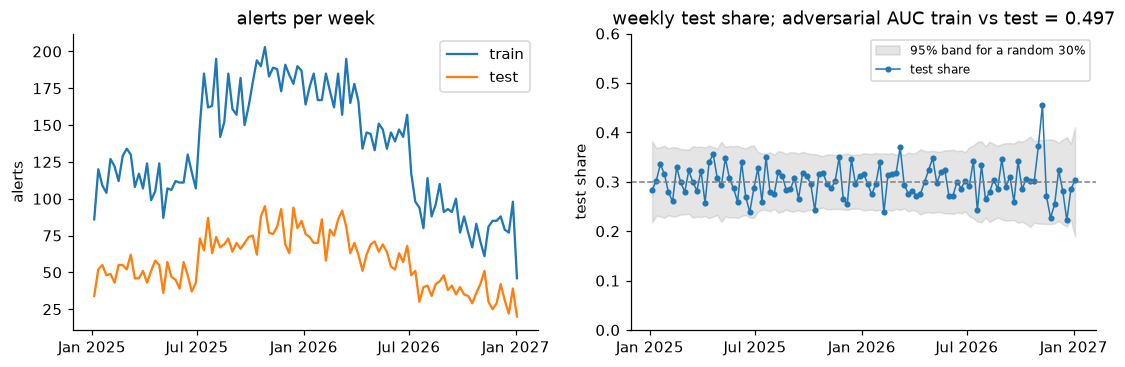

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
half_years = pd.date_range("2025-01-01", "2027-01-01", freq="6MS")
axes[0].plot(weekly.index, weekly["train"], label="train")
axes[0].plot(weekly.index, weekly["test"], label="test")
axes[0].set(title="alerts per week", ylabel="alerts", xticks=half_years, xticklabels=half_years.strftime("%b %Y"))
axes[0].legend()
axes[1].fill_between(weekly.index, test_share - band, test_share + band, color="grey", alpha=0.2, label="95% band for a random 30%")
axes[1].plot(weekly.index, weekly["test_share"], marker="o", ms=3, lw=1, label="test share")
axes[1].axhline(test_share, ls="--", c="grey", lw=1)
axes[1].set(title=f"weekly test share; adversarial AUC train vs test = {adv_auc_v0:.3f}", ylabel="test share", ylim=(0, 0.6), xticks=half_years, xticklabels=half_years.strftime("%b %Y"))
axes[1].legend(loc="upper right", fontsize=8)
save_fig(
    fig,
    "F02_alerts_per_week_train_test",
    "Train and test alerts rise and fall together week by week, and the weekly test share stays around 30% inside the band expected from a random draw. A classifier trained to tell test from train on the baseline totals scores AUC 0.497, no better than chance.",
    "The test set is a random sample of the same alerts: shuffled stratified K-fold on train estimates the hidden score, no time-based or drift correction is needed.",
)

The classifier cannot tell test from train (AUC 0.497) and no feature stands out in it: the top five take 4% to 5% of the gain each, close to the 3.4% an even spread over 29 columns would give. Week by week the two sets move together, through the same step up in July 2025 and the same steps down in 2026, and the test share stays within what a random 30% draw produces: 4 of 105 weeks fall outside the 95% band, fewer than the 5 expected by chance. The test set is the same population as train, so cross-validation on train is a fair estimate of the hidden score.

### Baseline model on the development folds

LightGBM on the 29 totals, trained and scored on the five development folds with early stopping inside each fold. Every run from here on is written to `cv_log.csv` with its fold scores, so later feature and model choices are compared on exactly the same folds. The log is rebuilt on every full run of the notebook.

In [40]:
LGB_PARAMS = dict(
    objective="binary", metric="auc", learning_rate=0.03, num_leaves=31, min_data_in_leaf=50,
    feature_fraction=0.7, bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0, seed=SEED,
    deterministic=True, force_col_wise=True, num_threads=4, verbose=-1,
)


def run_cv(X, y, folds, X_pred=(), params=LGB_PARAMS, seed=SEED):
    oof, preds, scores, imps = np.zeros(len(X)), [np.zeros(len(P)) for P in X_pred], [], []
    for tr, va in folds:
        bst = lgb.train(
            {**params, "seed": seed}, lgb.Dataset(X.iloc[tr], y[tr]), 10000,
            valid_sets=[lgb.Dataset(X.iloc[va], y[va])], callbacks=[lgb.early_stopping(200, verbose=False)],
        )
        oof[va] = bst.predict(X.iloc[va], num_iteration=bst.best_iteration)
        for p, P in zip(preds, X_pred):
            p += bst.predict(P, num_iteration=bst.best_iteration) / len(folds)
        scores.append(roc_auc_score(y[va], oof[va]))
        imps.append(pd.Series(bst.feature_importance("gain"), index=X.columns))
    return oof, preds, np.array(scores), pd.concat(imps, axis=1).mean(axis=1).sort_values(ascending=False)


LOG = ART_DIR / "cv_log.csv"
LOG.unlink(missing_ok=True)


def log_run(name, scores, n_feats, note=""):
    row = {
        "run": name, "cv_auc": round(float(scores.mean()), 5), "cv_std": round(float(scores.std()), 5),
        "gini": round(float(2 * scores.mean() - 1), 5), "folds": " ".join(f"{s:.4f}" for s in scores),
        "n_feats": n_feats, "note": note,
    }
    pd.DataFrame([row]).to_csv(LOG, mode="a", header=not LOG.exists(), index=False)
    return row


oof_v0, (pred_v0,), s_v0, _ = run_cv(X0_tr.iloc[dev_idx], y_dev, folds, [X0_te])
log_run("lgb_v0_baseline", s_v0, X0_tr.shape[1], "full-history totals, dev CV")

{'run': 'lgb_v0_baseline',
 'cv_auc': 0.61392,
 'cv_std': 0.01615,
 'gini': 0.22785,
 'folds': '0.6169 0.6247 0.6112 0.6319 0.5848',
 'n_feats': 29,
 'note': 'full-history totals, dev CV'}

The totals reach a development CV AUC of 0.614 (folds 0.585 to 0.632, Gini 0.23). There is some signal, but not much: six months of activity summed into one number per channel mixes the quiet background with the burst before the alert, and the audit showed those two look nothing alike. It is the reference for everything that follows: a feature family is kept when adding it to this baseline improves the out-of-fold AUC on these same folds. A single feature does not have to reach 0.614 on its own; one with a univariate AUC of 0.52 can still add information the totals lack.

In [41]:
X0_dev = X0_tr.iloc[dev_idx]
trees = [
    lgb.train(
        LGB_PARAMS, lgb.Dataset(X0_dev.iloc[tr], y_dev[tr]), 10000,
        valid_sets=[lgb.Dataset(X0_dev.iloc[va], y_dev[va])], callbacks=[lgb.early_stopping(200, verbose=False)],
    ).best_iteration
    for tr, va in folds
]
single = pd.Series({c: roc_auc_score(y_dev, X0_dev[c].fillna(X0_dev[c].min() - 1)) for c in X0_dev.columns})
single = 0.5 + (single - 0.5).abs()
pd.Series(
    {
        "pooled out-of-fold AUC": round(roc_auc_score(y_dev, oof_v0), 4),
        "trees kept by early stopping, per fold": " ".join(map(str, trees)),
        "best single total": single.idxmax(),
        "its AUC on its own": round(single.max(), 4),
    },
    dtype=object,
)

pooled out-of-fold AUC                                           0.6118
trees kept by early stopping, per fold                    44 86 21 39 5
best single total                         all_chiqim_bank_otkazmasi_max
its AUC on its own                                               0.5559
dtype: object

Pooling the out-of-fold predictions of all five folds gives 0.612, close to the fold mean. The baseline also says where the limit is. At a learning rate of 0.03, early stopping keeps only 5 to 86 trees per fold, so the model stops improving almost at once. The best single total, the largest outgoing bank transfer, reaches only 0.556 on its own. The baseline is feature-limited rather than model-limited: tuning it would change little, and the gain has to come from better features.

### Safety submission

The test set is scored by the average of the five development-fold models and written as `team_486052EC.csv`. The validator checks columns, row count, IDs, missing values, range and the file name, and it runs again on every later submission. This file is only a fallback that guarantees a valid submission exists; the final model overwrites it.

In [42]:
TEAM_ID = "486052EC"


def write_submission(test_sig, pred, team_id=TEAM_ID):
    sub = pd.DataFrame({"signal_id": test_sig["signal_id"].to_numpy(), "ehtimollik": np.clip(pred, 0, 1)})
    path = SUB_DIR / f"team_{team_id}.csv"
    sub.to_csv(path, index=False, float_format="%.6f")
    return path


def validate_submission(path, test_ids):
    s = pd.read_csv(path, dtype={"signal_id": "string"})
    assert list(s.columns) == ["signal_id", "ehtimollik"], f"columns: {list(s.columns)}"
    assert len(s) == len(test_ids), f"rows {len(s)} != {len(test_ids)}"
    assert s["signal_id"].is_unique, "duplicate IDs"
    assert set(s["signal_id"]) == set(test_ids), "missing or unknown IDs"
    assert np.isfinite(s["ehtimollik"]).all(), "NaN or inf predictions"
    assert s["ehtimollik"].between(0, 1).all(), "values outside [0, 1]"
    assert s["ehtimollik"].nunique() > 1, "constant predictions"
    assert path.name == f"team_{TEAM_ID}.csv", f"bad filename {path.name}"
    return {"rows": len(s), "md5": hashlib.md5(path.read_bytes()).hexdigest(), **s["ehtimollik"].describe()[["min", "50%", "max"]].round(4).to_dict()}


path = write_submission(te_sig, pred_v0)
validate_submission(path, te_sig["signal_id"])

{'rows': 6000,
 'md5': '6d42902c391c5c8ab23b554996d776df',
 'min': 0.1178,
 '50%': 0.1653,
 'max': 0.3239}

The file passes every check: 6,000 rows with each test ID once and predictions between 0.12 and 0.32 around a median of 0.17. The narrow range mirrors how little the totals separate the two classes.

### Validation design, frozen

Everything above fixes how the model will be judged, before any behavioural feature exists. None of it is reopened later.

| | Setting |
|---|---|
| Split | stratified 80/20, seed 42: 11,200 development alerts (1,924 escalated) and 2,800 holdout alerts (481 escalated), saved in `split.csv` |
| Development folds | one `StratifiedKFold(5, shuffle=True, random_state=42)` inside the development set, 2,240 alerts and 384 or 385 escalated per fold |
| Used for | every feature, screening, model, blend and tuning decision, compared as fold AUCs in `cv_log.csv` |
| Holdout | scored once, after features, preprocessing, models, hyperparameters and blend weights are frozen |
| Warning rule, fixed now | a warning if the pooled development out-of-fold AUC exceeds the holdout AUC by two bootstrap standard errors of the holdout AUC or more (about 0.025). A warning leads to a check on the development folds and a preference for the simpler configuration, never to tuning on the holdout. It is a warning threshold, not proof that the model generalizes |
| Final fit | the frozen configuration on the same five-fold recipe over all 14,000 alerts (`final_fold` in `split.csv`), test predictions averaged over the folds |
| Not needed | time-ordered folds (no drift in the monthly rate) and group-aware folds (no shared histories); the test set is interleaved with train week by week and adversarial AUC is 0.497 |

The holdout is a confirmation set for model development rather than a perfectly untouched one: its labels were part of the full-train summaries in the audit. It is still useful because no feature, model or blend choice will be optimized against it.

## Behavioural EDA on the development set

The audit left one main hypothesis: the burst before each alert, judged against the alert's own background, is what analysts react to. This section tests it and then looks at the rest of the history, on the development set only. Each history is split into three parts: the background (two or more days before the alert date), the trigger window (the alert day and the day before, `lag_days <= 1`) and the burst core (the last hour before the alert date begins). The classes are compared per alert rather than per transaction, so long histories do not dominate, using ECDFs and escalation rates by decile with 95% intervals.

With 1,924 escalated and 9,276 dismissed development alerts, a single univariate AUC has a standard error of 0.007 under chance, so values between 0.486 and 0.514 cannot be told from noise. Many variables are screened below, and a few will land just outside that band by luck, so only effects well outside it, or consistent across views, are acted on.

### Transaction activity over calendar time

First a view without labels: how transaction volume and the channel mix move over the calendar, in train and test.

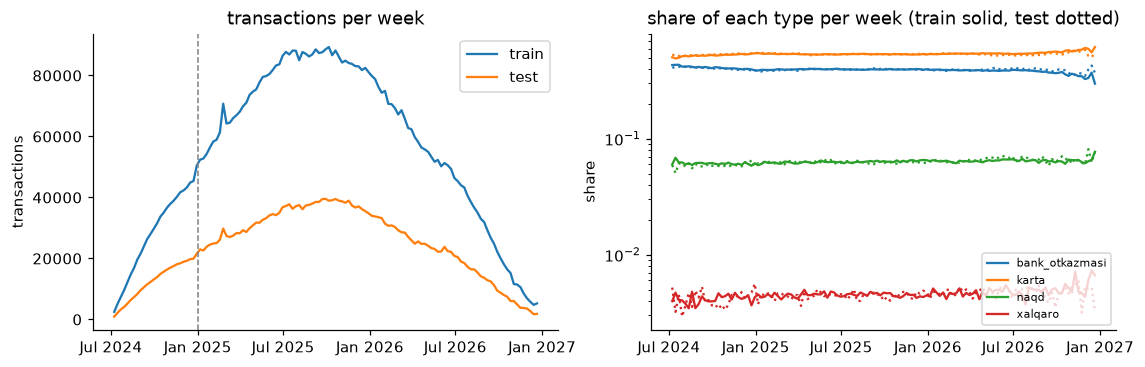

In [43]:
weekly_tx = pd.concat(
    {
        name: tx.groupby([tx["tranzaksiya_vaqti"].dt.normalize() - pd.to_timedelta(tx["tranzaksiya_vaqti"].dt.dayofweek, unit="D"), "tranzaksiya_turi"], observed=True).size().unstack()
        for name, tx in [("train", tr_tx), ("test", te_tx)]
    },
    axis=1,
).iloc[1:-1]
type_share = {name: weekly_tx[name].div(weekly_tx[name].sum(axis=1), axis=0) for name in ("train", "test")}

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(weekly_tx.index, weekly_tx["train"].sum(axis=1), label="train")
axes[0].plot(weekly_tx.index, weekly_tx["test"].sum(axis=1), label="test")
axes[0].axvline(pd.Timestamp("2025-01-01"), ls="--", c="grey", lw=1)
half_years = pd.date_range("2024-07-01", "2027-01-01", freq="6MS")
axes[0].set(title="transactions per week", ylabel="transactions", xticks=half_years, xticklabels=half_years.strftime("%b %Y"))
axes[0].legend()
for i, t in enumerate(type_share["train"].columns):
    axes[1].plot(type_share["train"].index, type_share["train"][t], color=f"C{i}", label=t)
    axes[1].plot(type_share["test"].index, type_share["test"][t], color=f"C{i}", ls=":")
axes[1].set(title="share of each type per week (train solid, test dotted)", ylabel="share", yscale="log", xticks=half_years, xticklabels=half_years.strftime("%b %Y"))
axes[1].legend(fontsize=7, loc="lower right")
save_fig(
    fig,
    "F05_weekly_transactions_by_type",
    "Weekly transaction volume rises from July 2024, when the earliest histories begin, peaks in late 2025 and falls through 2026, following how many alerts' 180-day windows cover each week; train and test move in parallel. The channel mix is flat over time in both sets (card 51-58%, transfers 35-42% of a week).",
    "No calendar-time features or drift corrections; describe behaviour relative to each alert's own window.",
)

In [44]:
busy = weekly_tx["test"].sum(axis=1) >= 5000
share_range = pd.concat({name: s[busy].agg(["min", "max"]).T for name, s in type_share.items()}, axis=1)
share_range.assign(weeks=int(busy.sum())).round(4)

train            test         weeks
                     min     max     min     max      
tranzaksiya_turi                                      
bank_otkazmasi    0.3485  0.4216  0.3518  0.4181   118
karta             0.5134  0.5803  0.5181  0.5820   118
naqd              0.0585  0.0672  0.0556  0.0714   118
xalqaro           0.0035  0.0056  0.0034  0.0056   118

Weekly volume rises from July 2024, when the earliest histories begin, peaks in late 2025 and falls through 2026. The shape follows how many alerts' 180-day windows cover each week (the alert-volume steps seen earlier, spread over half a year), not a change in behaviour, and train and test move in parallel at the ratio of their alert counts. The channel mix is flat: over the 118 weeks with at least 5,000 test transactions, card holds 51% to 58% of a week, transfers 35% to 42%, cash 5.6% to 7.1% and international 0.3% to 0.6%, in both sets. Calendar time adds nothing that the alert's own window does not already describe.

### Trigger window, burst core and background

Every transaction is tagged once with its direction × type channel and the part of the history it falls in. The table describes the three parts over all 14,000 training alerts, without labels.

In [45]:
TRIGGER_MAX_LAG = 1
BURST_SECS = 3600
BG_DAYS = 179


def add_parts(m):
    m = m.sort_values(["signal_id", "tranzaksiya_vaqti"], kind="stable", ignore_index=True)
    m["dir_type"] = pd.Categorical(m["kirim_chiqim"].astype(str) + "_" + m["tranzaksiya_turi"].astype(str), categories=DIR_TYPES)
    m["trigger"] = m["lag_days"] <= TRIGGER_MAX_LAG
    m["burst"] = m["secs_before"] <= BURST_SECS
    m["is_out"] = m["kirim_chiqim"] == "chiqim"
    m["is_cash"] = m["tranzaksiya_turi"] == "naqd"
    m["is_intl"] = m["tranzaksiya_turi"] == "xalqaro"
    return m


def part_summary(m, mask, sig):
    sub = m[mask]
    g = sub.groupby("signal_id")
    rows = g.size().reindex(sig["signal_id"], fill_value=0)
    span = (g["tranzaksiya_vaqti"].max() - g["tranzaksiya_vaqti"].min()).dt.total_seconds() / 60
    return pd.Series(
        {
            "share of all rows": mask.mean(),
            "alerts with no rows": int((rows == 0).sum()),
            "rows per alert, median": rows.median(),
            "span per alert, median minutes": span.median(),
            "outgoing share": sub["is_out"].mean(),
            "card share": (sub["tranzaksiya_turi"] == "karta").mean(),
            "bank transfer share": (sub["tranzaksiya_turi"] == "bank_otkazmasi").mean(),
            "cash share": sub["is_cash"].mean(),
            "international share": sub["is_intl"].mean(),
            "mean amount index": sub[VAL].mean(),
        }
    )


tr_m, te_m = add_parts(tr_m), add_parts(te_m)
PARTS = {"background, lag 2+": ~tr_m["trigger"], "trigger window, lag 0-1": tr_m["trigger"], "burst core, last hour": tr_m["burst"]}
pd.DataFrame({name: part_summary(tr_m, mask, tr_sig) for name, mask in PARTS.items()}).round(3)

,"background, lag 2+","trigger window, lag 0-1","burst core, last hour"
share of all rows,0.919,0.081,0.079
alerts with no rows,119.000,103.000,132.000
"rows per alert, median",421.500,31.000,31.000
"span per alert, median minutes",255158.583,135.233,2.783
outgoing share,0.243,0.249,0.249
card share,0.532,0.603,0.604
bank transfer share,0.401,0.323,0.322
cash share,0.063,0.068,0.068
international share,0.004,0.006,0.006
mean amount index,-0.101,-0.501,-0.506


In [46]:
rows_by_part = pd.DataFrame({name: tr_m[mask].groupby("signal_id").size() for name, mask in PARTS.items()}).reindex(tr_sig["signal_id"]).fillna(0)
ordinary_in_window = rows_by_part["trigger window, lag 0-1"] - rows_by_part["burst core, last hour"]
pd.Series(
    {
        "alerts with ordinary transactions inside the trigger window": int((ordinary_in_window > 0).sum()),
        "alerts whose burst sits earlier on the day before": int(((rows_by_part["burst core, last hour"] == 0) & (ordinary_in_window >= 10)).sum()),
        "alerts with no background at all": int((rows_by_part["background, lag 2+"] == 0).sum()),
    }
)

alerts with ordinary transactions inside the trigger window    7200
alerts whose burst sits earlier on the day before                10
alerts with no background at all                                119
dtype: int64

The background holds 92% of the rows (median 422 per alert) spread over about 177 days. The trigger window holds 8% (median 31), and almost all of it is the burst core: the burst itself spans a median 2.8 minutes, while the trigger window spans 135 minutes because 7,200 alerts also have a few ordinary transactions earlier on the day before. The burst has its own composition: more card (60% against 53%), fewer transfers (32% against 40%) and a mean amount index of −0.50 against −0.10, so it is a rapid run of small card payments. At the edges, 119 alerts have no background at all, so any change from the background is undefined for them, 132 have no burst core, and in 10 alerts the burst sits earlier on the day before, where the day-based window still catches it.

### One profile per alert

Class comparisons need one row per alert. The profile summarizes each part per alert (count, direction and channel shares, mean amount), the timing of the burst core, and how soon outflows follow inflows in the background. The trigger's rate relative to the background is its count divided by the background's daily rate, and each `delta_` column is trigger minus background. It is built for all training alerts and read on the development set only.

In [47]:
def part_profile(m, mask, tag):
    g = m[mask].groupby("signal_id")
    return pd.DataFrame(
        {
            f"{tag}_count": g.size(),
            f"{tag}_outgoing_share": g["is_out"].mean(),
            f"{tag}_cash_share": g["is_cash"].mean(),
            f"{tag}_international_share": g["is_intl"].mean(),
            f"{tag}_mean_amount": g[VAL].mean(),
        }
    )


def compression_profile(m):
    b = m[m["burst"]]
    sid, t = b["signal_id"], b["tranzaksiya_vaqti"]
    n = b.groupby("signal_id").size()
    gap = t.groupby(sid).diff().dt.total_seconds()
    f = pd.DataFrame(
        {
            "trigger_same_second_share": b.duplicated(["signal_id", "tranzaksiya_vaqti"], keep=False).groupby(sid).mean(),
            "trigger_duration_seconds": (t.groupby(sid).max() - t.groupby(sid).min()).dt.total_seconds(),
            "trigger_median_gap_seconds": gap.groupby(sid).median(),
        }
    )
    f["trigger_tx_per_minute"] = n / (f["trigger_duration_seconds"] / 60).clip(lower=1 / 60)
    f["dormancy_before_burst_h"] = (t.groupby(sid).min() - m[~m["burst"]].groupby("signal_id")["tranzaksiya_vaqti"].max()).dt.total_seconds() / 3600
    return f


def flow_profile(m):
    bg = m[~m["trigger"]]
    sid = bg["signal_id"]
    last_in = bg["tranzaksiya_vaqti"].where(~bg["is_out"]).groupby(sid).ffill()
    h_in_out = ((bg["tranzaksiya_vaqti"] - last_in).dt.total_seconds() / 3600).where(bg["is_out"])
    n_out = bg["is_out"].groupby(sid).sum().replace(0, np.nan)
    return pd.DataFrame(
        {
            "background_out_within_24h_of_in_share": (h_in_out <= 24).groupby(sid).sum() / n_out,
            "background_median_h_in_to_out": h_in_out.groupby(sid).median(),
            "background_in_out_ratio": (~bg["is_out"]).groupby(sid).sum() / n_out,
        }
    )


prof = pd.concat(
    [
        part_profile(tr_m, ~tr_m["trigger"], "background"),
        part_profile(tr_m, tr_m["trigger"], "trigger"),
        part_profile(tr_m, tr_m["burst"], "core"),
        compression_profile(tr_m),
        flow_profile(tr_m),
    ],
    axis=1,
).reindex(tr_sig["signal_id"])
counts = prof.columns[prof.columns.str.endswith("_count")]
prof[counts] = prof[counts].fillna(0)
prof["trigger_rate_ratio"] = prof["trigger_count"] / (prof["background_count"].replace(0, np.nan) / BG_DAYS)
for s in ("outgoing_share", "cash_share", "international_share", "mean_amount"):
    prof[f"delta_{s}"] = prof[f"trigger_{s}"] - prof[f"background_{s}"]
dev_prof = prof.iloc[dev_idx].reset_index(drop=True)
n1, n0 = int(y_dev.sum()), int((y_dev == 0).sum())
AUC_SE = np.sqrt((n0 + n1 + 1) / (12 * n0 * n1))


def univariate_auc(X, y, folds):
    rows = {}
    for c in X.columns:
        x, ok = X[c].to_numpy(dtype=float), X[c].notna().to_numpy()
        fold_auc = [roc_auc_score(y[va][ok[va]], x[va][ok[va]]) for _, va in folds]
        rows[c] = {"auc": roc_auc_score(y[ok], x[ok]), "fold_min": min(fold_auc), "fold_max": max(fold_auc), "missing": 1 - ok.mean()}
    return pd.DataFrame(rows).T


def plot_rate_by_bin(x, y, name, ax):
    g = rate_by_bin(x, y)
    ax.errorbar(range(len(g)), g["rate"], yerr=[g["rate"] - g["lo"], g["hi"] - g["rate"]], marker="o", ms=3, capsize=2, color=CLASS_COLORS[1])
    ax.axhline(np.mean(y), ls="--", c="grey", lw=1)
    ax.set_title(name, fontsize=9)
    ax.set(ylim=(0.05, 0.3))


def ecdf_by_class(x, y, ax, label, logx=False):
    for k in (0, 1):
        v = np.sort(x[(y == k) & ~np.isnan(x)])
        ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=CLASS_COLORS[k], label=["dismissed", "escalated"][k])
    ax.set(xlabel=label, ylabel="share of alerts", xscale="log" if logx else "linear")


prof.shape, round(AUC_SE, 4)

((14000, 28), np.float64(0.0072))

### Background volume

Do escalated alerts simply have more activity? Background transactions per alert, as an ECDF on a log scale and as the escalation rate by decile.

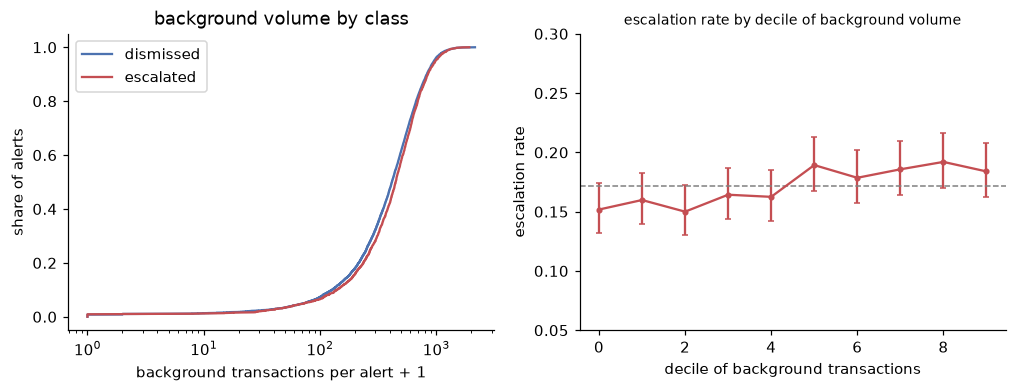

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
ecdf_by_class(dev_prof["background_count"].to_numpy(dtype=float) + 1, y_dev, axes[0], "background transactions per alert + 1", logx=True)
axes[0].legend()
axes[0].set_title("background volume by class")
plot_rate_by_bin(dev_prof["background_count"], y_dev, "escalation rate by decile of background volume", axes[1])
axes[1].set(xlabel="decile of background transactions", ylabel="escalation rate")
save_fig(
    fig,
    "F03_background_volume_by_class",
    "Escalated alerts have slightly more background activity (median 447 vs 415 transactions, AUC 0.527); the ECDFs nearly overlap and the escalation rate rises only from about 15% to 19% across deciles.",
    "Keep background counts as a weak input; volume alone will not separate the classes.",
)

In [49]:
pd.Series(
    {
        "median background transactions, dismissed": dev_prof.loc[y_dev == 0, "background_count"].median(),
        "median background transactions, escalated": dev_prof.loc[y_dev == 1, "background_count"].median(),
        "AUC background volume": round(roc_auc_score(y_dev, dev_prof["background_count"]), 4),
        "AUC standard error under chance": round(AUC_SE, 4),
    },
    dtype=object,
)

median background transactions, dismissed     415.0
median background transactions, escalated     447.0
AUC background volume                        0.5272
AUC standard error under chance              0.0072
dtype: object

Slightly. Escalated alerts have a median of 447 background transactions against 415, and the escalation rate climbs from about 15% in the lower deciles to about 19% in the upper ones, but the ECDFs nearly overlap and the AUC is 0.527. Volume is a weak signal on its own.

### Background activity before the alert

If behaviour changes in the weeks before an alert, the class curves should separate as the alert approaches, and that would set the background windows. Transactions per alert per day at lags 2 to 180, by class.

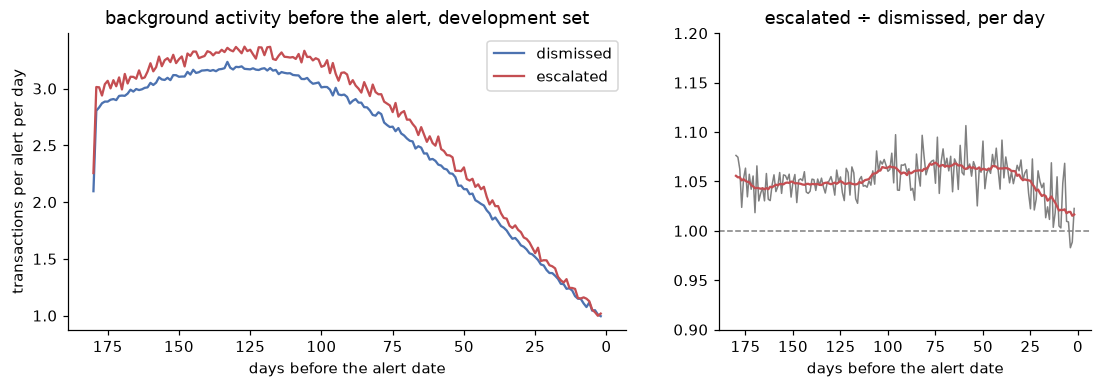

In [50]:
def activity_curve(m, sig):
    lab = sig.set_index("signal_id")[TARGET]
    sub = m[m["signal_id"].isin(lab.index)]
    cnt = sub.groupby([sub["signal_id"].map(lab).rename(TARGET), "lag_days"]).size()
    return (cnt / lab.value_counts().reindex(cnt.index.get_level_values(0)).to_numpy()).unstack(0)


curve = activity_curve(tr_m, dev_sig)
background_ratio = curve.loc[2:, 1] / curve.loc[2:, 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), gridspec_kw={"width_ratios": [3, 2]})
for k in (0, 1):
    axes[0].plot(curve.loc[2:].index, curve.loc[2:, k], color=CLASS_COLORS[k], label=["dismissed", "escalated"][k])
axes[0].invert_xaxis()
axes[0].set(title="background activity before the alert, development set", xlabel="days before the alert date", ylabel="transactions per alert per day")
axes[0].legend()
axes[1].plot(background_ratio.index, background_ratio, color="grey", lw=1)
axes[1].plot(background_ratio.index, background_ratio.rolling(15, center=True, min_periods=5).mean(), color=CLASS_COLORS[1])
axes[1].axhline(1, ls="--", c="grey", lw=1)
axes[1].invert_xaxis()
axes[1].set(title="escalated ÷ dismissed, per day", xlabel="days before the alert date", ylim=(0.9, 1.2))
save_fig(
    fig,
    "F06_background_activity_by_class",
    "Background activity has the same shape for both classes; escalated alerts run about 5% higher at every lag from 2 to 180 days (median ratio 1.055) with no build-up towards the alert.",
    "No special pre-alert window: background activity enters as a level, and 7/30/90-day windows stay default candidates only.",
)

In [51]:
pd.Series(
    {
        "ratio escalated / dismissed, lags 2-180, median": background_ratio.median(),
        "lowest day": background_ratio.min(),
        "highest day": background_ratio.max(),
        "median ratio, lags 2-30": background_ratio.loc[2:30].median(),
        "median ratio, lags 151-180": background_ratio.loc[151:180].median(),
        "spearman, lag vs ratio": spearmanr(background_ratio.index, background_ratio).statistic,
        "trigger window per alert, dismissed": curve.loc[[0, 1], 0].sum(),
        "trigger window per alert, escalated": curve.loc[[0, 1], 1].sum(),
    }
).round(3)

ratio escalated / dismissed, lags 2-180, median     1.055
lowest day                                          0.983
highest day                                         1.106
median ratio, lags 2-30                             1.032
median ratio, lags 151-180                          1.049
spearman, lag vs ratio                             -0.069
trigger window per alert, dismissed                40.563
trigger window per alert, escalated                41.927
dtype: float64

The two curves have the same shape: both rise to about 3 a day around four months out and fall to about 1 a day just before the alert. Escalated alerts sit about 5% higher at every lag (median ratio 1.055, between 0.98 and 1.11 on single days), and the gap does not grow towards the alert: the ratio is 1.03 in the last month and 1.05 five months out, with no consistent trend (Spearman −0.07). The trigger window holds 41.9 transactions per escalated alert against 40.6 per dismissed one, a similar 3% gap. There is no build-up before escalated alerts, so the curves give no reason for any particular background window; 7, 30 and 90 days stay as default candidates only.

### Trigger-window test

The compact test from the review: thirteen variables that describe the trigger itself (size, direction, channel, amount, speed) or its change from the alert's own background. For each, the univariate AUC with its range over the five folds, the missing share, and the escalation rate by decile. The question is whether the trigger level is predictive, the change from the background, or neither.

In [52]:
TRIGGER_TEST = [
    "trigger_count", "trigger_rate_ratio",
    "trigger_outgoing_share", "delta_outgoing_share",
    "trigger_cash_share", "delta_cash_share",
    "trigger_international_share", "delta_international_share",
    "trigger_mean_amount", "delta_mean_amount",
    "trigger_same_second_share", "trigger_tx_per_minute", "trigger_median_gap_seconds",
]
trigger_screen = univariate_auc(dev_prof[TRIGGER_TEST], y_dev, folds)
trigger_screen["beyond chance"] = (trigger_screen["auc"] - 0.5).abs() > 1.96 * AUC_SE
trigger_screen.round(4)

,auc,fold_min,fold_max,missing,beyond chance
trigger_count,0.5127,0.4961,0.5393,0.0000,False
trigger_rate_ratio,0.4939,0.4846,0.5042,0.0084,False
trigger_outgoing_share,0.5280,0.5042,0.5416,0.0073,True
delta_outgoing_share,0.5201,0.4864,0.5430,0.0157,True
trigger_cash_share,0.5194,0.4861,0.5452,0.0073,True
delta_cash_share,0.5074,0.4671,0.5283,0.0157,False
trigger_international_share,0.5093,0.4995,0.5253,0.0073,False
delta_international_share,0.4953,0.4904,0.5057,0.0157,False
trigger_mean_amount,0.4705,0.4599,0.4867,0.0073,True
delta_mean_amount,0.5128,0.4961,0.5221,0.0157,False


In [53]:
_, _, s_trigger, _ = run_cv(dev_prof[TRIGGER_TEST], y_dev, folds)
pd.Series({"13 trigger variables together, dev CV AUC": s_trigger.mean(), "fold min": s_trigger.min(), "fold max": s_trigger.max()}).round(4)

13 trigger variables together, dev CV AUC    0.5469
fold min                                     0.5404
fold max                                     0.5562
dtype: float64

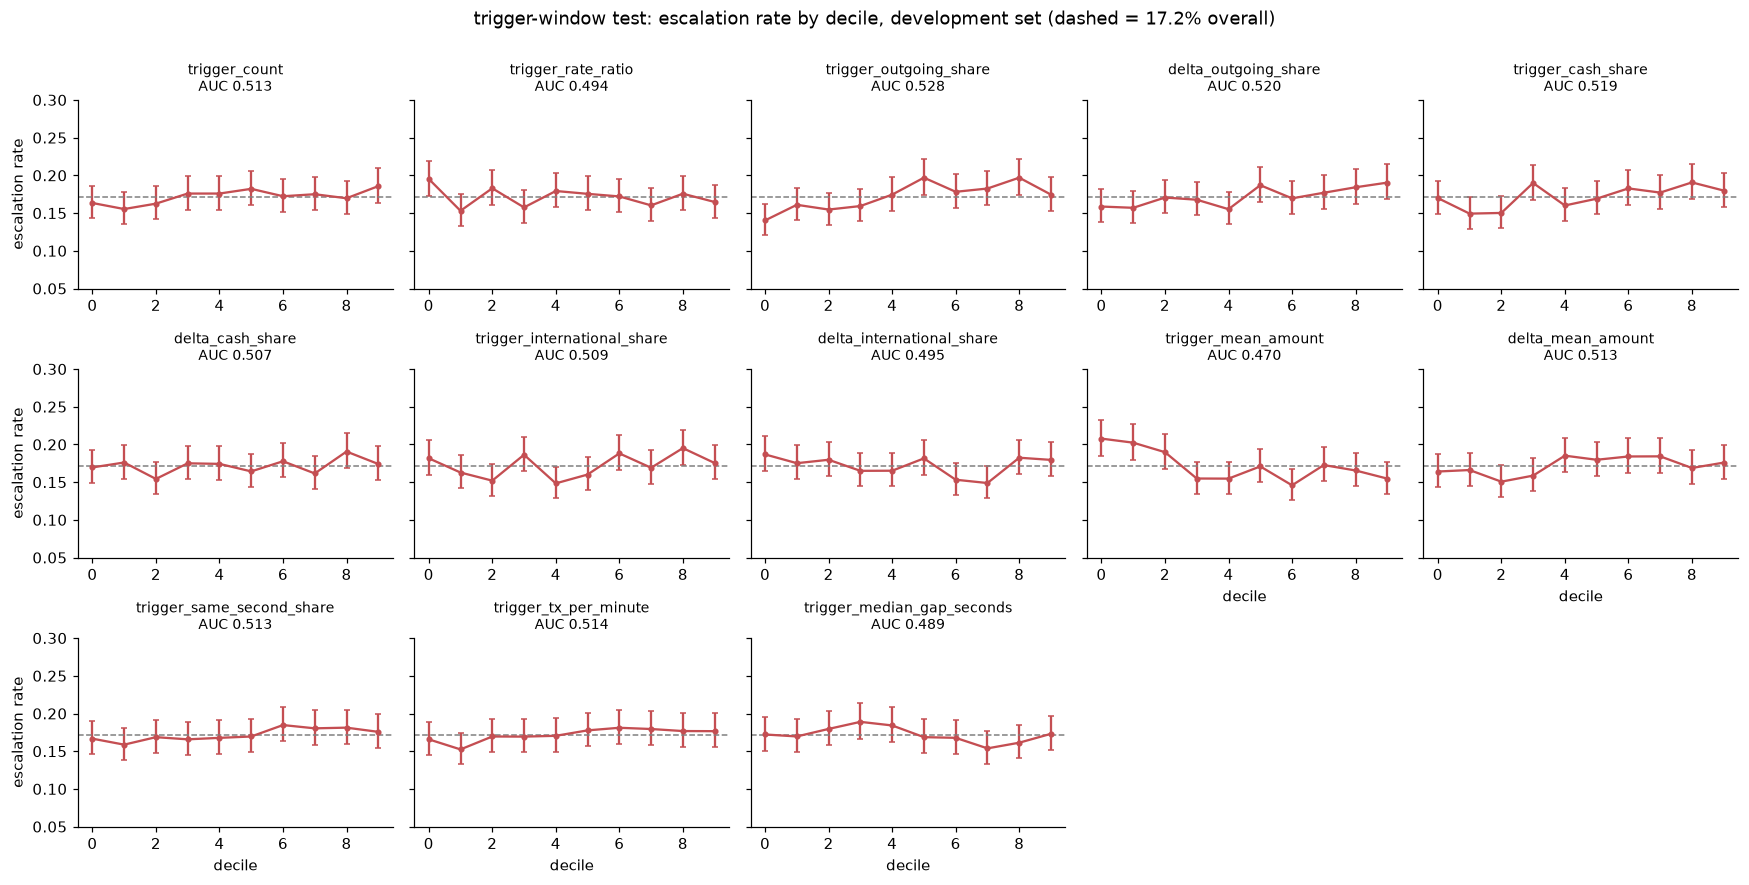

In [54]:
fig, axes = plt.subplots(3, 5, figsize=(16, 8), sharey=True)
for c, ax in zip(TRIGGER_TEST, axes.ravel()):
    plot_rate_by_bin(dev_prof[c], y_dev, f"{c}\nAUC {trigger_screen.loc[c, 'auc']:.3f}", ax)
for ax in axes.ravel()[len(TRIGGER_TEST):]:
    ax.set_visible(False)
for ax in axes.ravel()[len(TRIGGER_TEST) - 5:len(TRIGGER_TEST)]:
    ax.set_xlabel("decile")
for ax in axes[:, 0]:
    ax.set_ylabel("escalation rate")
fig.suptitle("trigger-window test: escalation rate by decile, development set (dashed = 17.2% overall)", y=1.0)
fig.tight_layout()
save_fig(
    fig,
    "F04_trigger_test_by_decile",
    "None of the 13 trigger variables separates the classes on its own: AUCs 0.470-0.528, trigger size relative to the background 0.494, decile rates flat around 17%. Together they reach a CV AUC of 0.547, below the 0.614 of the plain totals.",
    "Trigger test answer: neither the level nor the change is predictive on its own. Keep a compact trigger family for the ablation only, at low priority.",
)

Neither, on its own. All thirteen AUCs lie between 0.470 and 0.528 and the decile curves stay flat around the 17.2% line. The trigger's size relative to the background, the lead candidate, scores 0.494, and no change variable gets further than 0.02 from chance. Four variables pass the single-test chance band: the trigger's outgoing share (0.528), its change from the background (0.520), its cash share (0.519) and its mean amount (0.470); with thirteen tests, about one would pass by luck alone. The mean amount is worth a note: its change from the background scores only 0.513, so what it carries is the alert's general amount level, which the amount section below takes up. Used together in one model, the thirteen variables reach a CV AUC of 0.547, well below the 0.614 of the plain totals. The burst is a structural feature of every alert, but on this evidence it is not what separates escalated from dismissed ones.

### Trigger boundary

The trigger window (`lag_days <= 1`) also holds ordinary transactions for 7,200 alerts, while the burst core (the last hour) misses the 10 bursts that sit earlier on the day before. The composition variables are compared under both boundaries.

In [55]:
boundary = pd.DataFrame(
    {
        "trigger window, lag 0-1": univariate_auc(dev_prof.filter(regex="^trigger_(count|outgoing_share|cash_share|international_share|mean_amount)$").rename(columns=lambda c: c.replace("trigger_", "")), y_dev, folds)["auc"],
        "burst core, last hour": univariate_auc(dev_prof.filter(regex="^core_").rename(columns=lambda c: c.replace("core_", "")), y_dev, folds)["auc"],
    }
)
boundary.round(4)

,"trigger window, lag 0-1","burst core, last hour"
count,0.5127,0.5113
outgoing_share,0.5280,0.5282
cash_share,0.5194,0.5188
international_share,0.5093,0.5093
mean_amount,0.4705,0.4710


The two boundaries give AUCs within 0.002 of each other. `lag_days <= 1` stays for counts, shares and amounts, because it also catches the early bursts. Timing variables (compression and the silence before the burst) use the burst core, where a few ordinary transactions from earlier in the day would otherwise stretch a 2.8-minute burst to 135 minutes.

### Burst compression

A burst that is faster or more concentrated than usual could look like automated or coordinated activity. Same-second share, transactions per minute, duration, median gap and the silence before the burst, measured on the burst core.

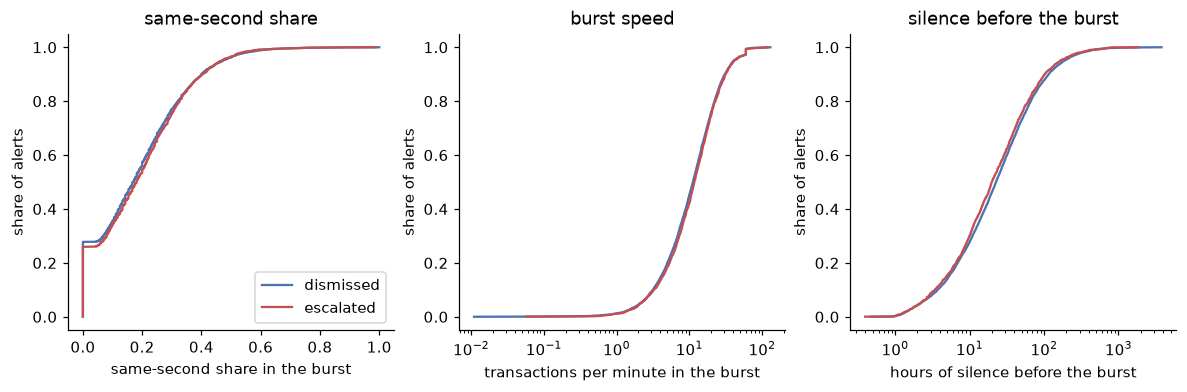

In [56]:
COMPRESSION = ["trigger_same_second_share", "trigger_tx_per_minute", "trigger_duration_seconds", "trigger_median_gap_seconds", "dormancy_before_burst_h"]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
ecdf_by_class(dev_prof["trigger_same_second_share"].to_numpy(dtype=float), y_dev, axes[0], "same-second share in the burst")
ecdf_by_class(dev_prof["trigger_tx_per_minute"].to_numpy(dtype=float), y_dev, axes[1], "transactions per minute in the burst", logx=True)
ecdf_by_class(dev_prof["dormancy_before_burst_h"].to_numpy(dtype=float) + 0.01, y_dev, axes[2], "hours of silence before the burst", logx=True)
axes[0].legend()
for ax, name in zip(axes, ["same-second share", "burst speed", "silence before the burst"]):
    ax.set_title(name)
save_fig(
    fig,
    "F10_burst_compression_by_class",
    "Burst compression is the same for both classes: same-second share, transactions per minute, duration and median gap score AUC 0.489-0.514; the silence before the burst is slightly shorter for escalated alerts (0.480).",
    "Compression features are low priority; test them only as a small family.",
)

In [57]:
univariate_auc(dev_prof[COMPRESSION], y_dev, folds).round(4)

,auc,fold_min,fold_max,missing
trigger_same_second_share,0.5130,0.5021,0.5350,0.0095
trigger_tx_per_minute,0.5142,0.4988,0.5296,0.0095
trigger_duration_seconds,0.5056,0.4817,0.5363,0.0095
trigger_median_gap_seconds,0.4892,0.4713,0.5052,0.0308
dormancy_before_burst_h,0.4801,0.4529,0.4919,0.0164


The class ECDFs lie on top of each other and the AUCs stay between 0.480 and 0.514. The silence before the burst comes closest (0.480: escalated bursts follow a slightly shorter quiet spell, in line with their slightly busier background), but the effect is small. Compression is not what separates escalated alerts.

### Incoming and outgoing

Pass-through, money that arrives and leaves again quickly, is a classic laundering pattern, and a trigger that turns outgoing would be a red flag. Outgoing shares for the background and the trigger, their change, and how soon outflows follow inflows in the background.

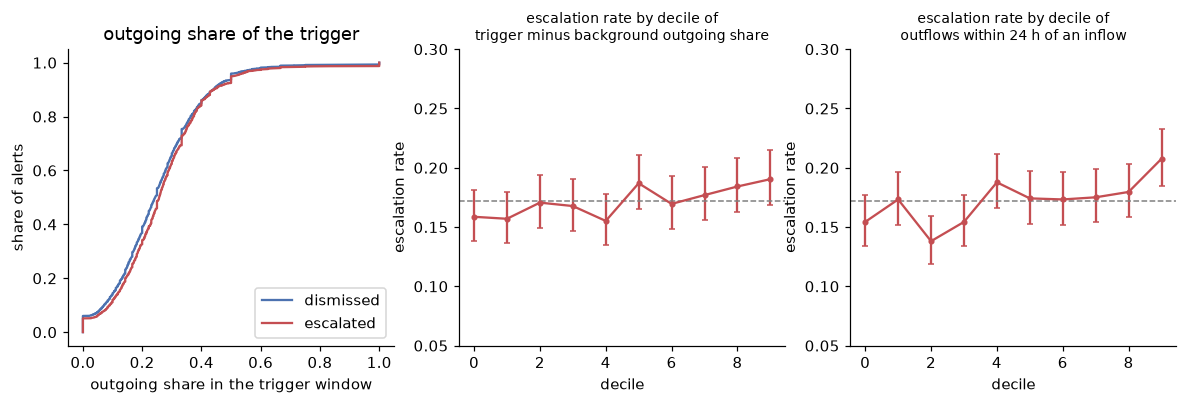

In [58]:
FLOW = [
    "background_outgoing_share", "trigger_outgoing_share", "delta_outgoing_share",
    "background_out_within_24h_of_in_share", "background_median_h_in_to_out", "background_in_out_ratio",
]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
ecdf_by_class(dev_prof["trigger_outgoing_share"].to_numpy(dtype=float), y_dev, axes[0], "outgoing share in the trigger window")
axes[0].legend()
axes[0].set_title("outgoing share of the trigger")
plot_rate_by_bin(dev_prof["delta_outgoing_share"], y_dev, "escalation rate by decile of\ntrigger minus background outgoing share", axes[1])
plot_rate_by_bin(dev_prof["background_out_within_24h_of_in_share"], y_dev, "escalation rate by decile of\noutflows within 24 h of an inflow", axes[2])
for ax in axes[1:]:
    ax.set(xlabel="decile", ylabel="escalation rate")
save_fig(
    fig,
    "F07_incoming_outgoing_by_class",
    "Escalated alerts lean slightly towards pass-through: a more outgoing trigger (AUC 0.528), more outflows within 24 h of an inflow (0.526) and a shorter inflow-to-outflow time (0.478). The direction is consistent, the effects are small.",
    "Keep in-to-out timing and outgoing shares as a small typology family.",
)

In [59]:
univariate_auc(dev_prof[FLOW], y_dev, folds).round(4)

,auc,fold_min,fold_max,missing
background_outgoing_share,0.5131,0.4892,0.5341,0.0084
trigger_outgoing_share,0.5280,0.5042,0.5416,0.0073
delta_outgoing_share,0.5201,0.4864,0.5430,0.0157
background_out_within_24h_of_in_share,0.5256,0.5106,0.5524,0.0107
background_median_h_in_to_out,0.4775,0.4488,0.4886,0.0117
background_in_out_ratio,0.4873,0.4674,0.5093,0.0107


Direction carries a little signal, but only a little. Escalated triggers are slightly more outgoing (AUC 0.528, the largest of the trigger variables), outflows within 24 hours of an inflow are slightly more common (0.526) and the median time from an inflow to the next outflow is slightly shorter (0.478). All three point the same way, towards pass-through, and all three are small: the decile rates move by a few points at most.

### Channel mix

Which channels an alert uses in its background and in its trigger, and whether the trigger shifts the mix towards cash or international transfers. Shares are computed per alert and then averaged.

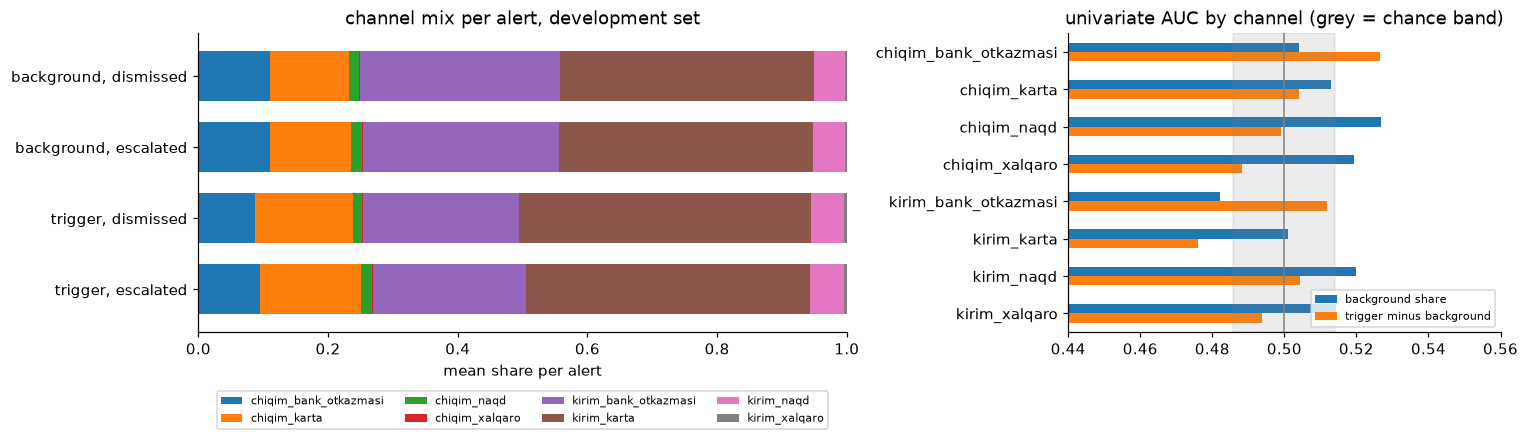

In [60]:
def type_shares(m, mask, sig):
    s = m[mask].groupby(["signal_id", "dir_type"], observed=False).size().unstack()
    return s.div(s.sum(axis=1), axis=0).reindex(sig["signal_id"]).reset_index(drop=True)


mix = {"background": type_shares(tr_m, ~tr_m["trigger"], dev_sig), "trigger": type_shares(tr_m, tr_m["trigger"], dev_sig)}
mean_mix = pd.DataFrame({f"{part}, {['dismissed', 'escalated'][k]}": s[y_dev == k].mean() for part, s in mix.items() for k in (0, 1)}).T

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [3, 2]})
mean_mix.plot.barh(stacked=True, ax=axes[0], width=0.7, legend=False)
axes[0].invert_yaxis()
axes[0].set(title="channel mix per alert, development set", xlabel="mean share per alert", xlim=(0, 1))
axes[0].legend(fontsize=7, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.18))
delta_mix = mix["trigger"] - mix["background"]
mix_auc = pd.DataFrame(
    {
        "background share": univariate_auc(mix["background"], y_dev, folds)["auc"],
        "trigger minus background": univariate_auc(delta_mix, y_dev, folds)["auc"],
    }
)
mix_auc.plot.barh(ax=axes[1])
axes[1].axvline(0.5, c="grey", lw=1)
axes[1].axvspan(0.5 - 1.96 * AUC_SE, 0.5 + 1.96 * AUC_SE, color="grey", alpha=0.15)
axes[1].invert_yaxis()
axes[1].set(title="univariate AUC by channel (grey = chance band)", xlim=(0.44, 0.56))
axes[1].legend(fontsize=7, loc="lower right")
fig.tight_layout()
save_fig(
    fig,
    "F08_channel_mix_by_class",
    "The trigger shifts the mix towards card and away from transfers in the same way for both classes; every background share and every trigger-minus-background change scores AUC 0.476-0.527.",
    "Channel shares and their changes are low priority: channels matter through their amounts, not through the mix.",
)

In [61]:
mix_auc.round(4)

,background share,trigger minus background
chiqim_bank_otkazmasi,0.5042,0.5265
chiqim_karta,0.5129,0.5040
chiqim_naqd,0.5268,0.4992
chiqim_xalqaro,0.5193,0.4883
kirim_bank_otkazmasi,0.4823,0.5117
kirim_karta,0.5011,0.4759
kirim_naqd,0.5200,0.5043
kirim_xalqaro,0.5143,0.4938


The trigger has a different mix from the background, more card and fewer transfers, but the shift is the same for both classes: the four bars pair up by part, not by class. Every background share and every change in share scores between 0.476 and 0.527. Which channels an alert uses says little about its outcome.

### Transaction sequences

Transaction order: the share of each consecutive pair of channels within an alert, compared with what random order would give and between the classes. Pairs below 0.2% of all transitions are left blank in the class comparison, because their ratios are dominated by noise.

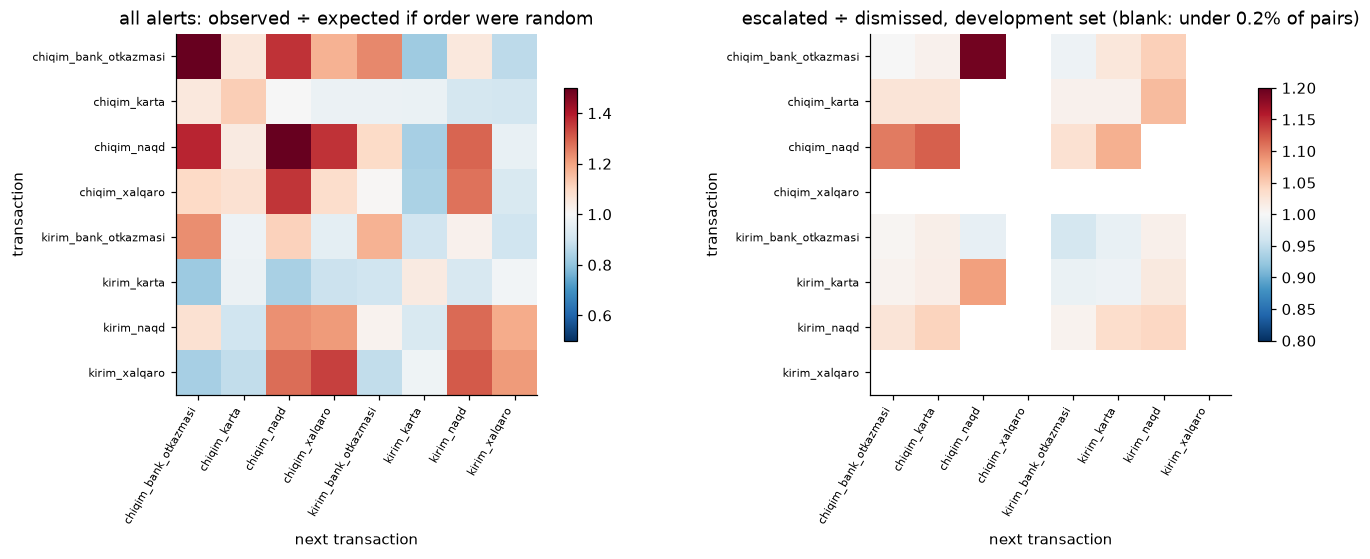

In [62]:
def transition_shares(m):
    sid, code = m["signal_id"].to_numpy(), m["dir_type"].cat.codes.to_numpy().astype(np.int64)
    keep = sid[1:] == sid[:-1]
    k = len(DIR_TYPES)
    pairs = pd.DataFrame({"signal_id": sid[:-1][keep], "pair": code[:-1][keep] * k + code[1:][keep]})
    t = pairs.groupby(["signal_id", "pair"]).size().unstack(fill_value=0).reindex(columns=range(k * k), fill_value=0)
    t = t.div(t.sum(axis=1), axis=0)
    t.columns = [f"{DIR_TYPES[p // k]} > {DIR_TYPES[p % k]}" for p in t.columns]
    return t


seq_dev = transition_shares(tr_m).reindex(dev_sig["signal_id"]).reset_index(drop=True)
seq_class = seq_dev.groupby(y_dev).mean()
common = (seq_dev.mean() >= 0.002).to_numpy()
lift = np.where(common, seq_class.loc[1] / seq_class.loc[0], np.nan).reshape(len(DIR_TYPES), len(DIR_TYPES))
type_share_all = tr_m["dir_type"].value_counts(normalize=True).reindex(DIR_TYPES).to_numpy()
vs_independent = (seq_dev.mean().to_numpy() / np.outer(type_share_all, type_share_all).ravel()).reshape(len(DIR_TYPES), len(DIR_TYPES))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, grid, title, lim in [
    (axes[0], vs_independent, "all alerts: observed ÷ expected if order were random", (0.5, 1.5)),
    (axes[1], lift, "escalated ÷ dismissed, development set (blank: under 0.2% of pairs)", (0.8, 1.2)),
]:
    im = ax.imshow(grid, cmap="RdBu_r", vmin=lim[0], vmax=lim[1])
    ax.set_xticks(range(len(DIR_TYPES)), DIR_TYPES, rotation=60, ha="right", fontsize=7)
    ax.set_yticks(range(len(DIR_TYPES)), DIR_TYPES, fontsize=7)
    ax.set(title=title, xlabel="next transaction", ylabel="transaction")
    fig.colorbar(im, ax=ax, shrink=0.7)
fig.tight_layout()
save_fig(
    fig,
    "F11_transition_lift",
    "Transaction order is not random (same-channel repeats are over-represented, outgoing cash after outgoing cash 1.74x), but the pattern is the same for both classes: over the common pairs the escalated/dismissed ratio is 0.96-1.19 and no transition is more than 0.03 from AUC 0.5.",
    "Sequence features are low priority.",
)

In [63]:
seq_auc = univariate_auc(seq_dev, y_dev, folds)
pd.Series(
    {
        "transitions tested": len(seq_auc),
        "largest |AUC - 0.5|": (seq_auc["auc"] - 0.5).abs().max(),
        "beyond the chance band": int(((seq_auc["auc"] - 0.5).abs() > 1.96 * AUC_SE).sum()),
        "common pairs, at least 0.2% of transitions": int(common.sum()),
        "lift range over common pairs, escalated / dismissed": f"{np.nanmin(lift):.2f} to {np.nanmax(lift):.2f}",
        "most over-represented pair overall": f"{seq_dev.columns[np.nanargmax(vs_independent)]} ({np.nanmax(vs_independent):.2f}x)",
    },
    dtype=object,
)

transitions tested                                                                    64
largest |AUC - 0.5|                                                             0.029784
beyond the chance band                                                                17
common pairs, at least 0.2% of transitions                                            32
lift range over common pairs, escalated / dismissed                         0.96 to 1.19
most over-represented pair overall                     chiqim_naqd > chiqim_naqd (1.74x)
dtype: object

Order is not random. Consecutive transactions repeat their channel more often than chance would, most of all outgoing cash followed by outgoing cash (1.74 times the random rate). But the pattern is the same for both classes: over the 32 common pairs the escalated-to-dismissed ratio stays between 0.96 and 1.19, and no transition gets further than 0.03 from an AUC of 0.5. Seventeen of the 64 transitions pass the single-test band, more than chance would give, but they echo the small channel effects already seen rather than add a sequence effect of their own.

### Amounts within each channel

Amounts are compared on each channel's own scale: every transaction's index is standardized by the mean and standard deviation of its direction × type channel, taken from train and test transactions together without labels. For each channel the per-alert background mean is compared between the classes, with the share above the channel's own 95th percentile as a second view.

In [64]:
def channel_stats(*ms):
    a = pd.concat([m[["dir_type", VAL]] for m in ms], ignore_index=True)
    g = a.groupby("dir_type", observed=False)[VAL]
    return pd.DataFrame({"mean": g.mean(), "std": g.std(), "p95": g.quantile(0.95), "p99": g.quantile(0.99)})


def add_amount_cols(m, ch):
    code, v = m["dir_type"].cat.codes.to_numpy(), m[VAL].to_numpy()
    m["channel_z"] = (v - ch["mean"].to_numpy()[code]) / ch["std"].to_numpy()[code]
    m["above_p95"] = v > ch["p95"].to_numpy()[code]
    return m


def channel_profile(m, mask, sig):
    g = m[mask].groupby(["signal_id", "dir_type"], observed=False)
    z = g["channel_z"].mean().unstack()
    tail = g["above_p95"].mean().unstack()
    return z.reindex(sig["signal_id"]).reset_index(drop=True), tail.reindex(sig["signal_id"]).reset_index(drop=True)


CH = channel_stats(tr_m, te_m)
tr_m, te_m = add_amount_cols(tr_m, CH), add_amount_cols(te_m, CH)
bg_z, bg_p95 = channel_profile(tr_m, ~tr_m["trigger"], dev_sig)
gap = pd.DataFrame(
    {
        "escalated minus dismissed, channel sd": bg_z[y_dev == 1].mean() - bg_z[y_dev == 0].mean(),
        "ci95": 1.96 * np.sqrt(bg_z[y_dev == 1].var() / bg_z[y_dev == 1].count() + bg_z[y_dev == 0].var() / bg_z[y_dev == 0].count()),
        "AUC channel mean": univariate_auc(bg_z, y_dev, folds)["auc"],
        "AUC share above channel p95": univariate_auc(bg_p95, y_dev, folds)["auc"],
        "alerts using the channel": bg_z.notna().mean(),
    }
)
gap.round(4)

,"escalated minus dismissed, channel sd",ci95,AUC channel mean,AUC share above channel p95,alerts using the channel
chiqim_bank_otkazmasi,-0.1454,0.0283,0.4259,0.4481,0.9854
chiqim_karta,-0.0081,0.0279,0.4951,0.5075,0.9856
chiqim_naqd,-0.0612,0.0379,0.4772,0.4880,0.9054
chiqim_xalqaro,-0.1899,0.0772,0.4438,0.4847,0.3321
kirim_bank_otkazmasi,-0.1187,0.0267,0.4392,0.4395,0.9900
kirim_karta,-0.0508,0.0269,0.4698,0.4780,0.9891
kirim_naqd,0.0145,0.0341,0.5054,0.5097,0.9712
kirim_xalqaro,-0.0890,0.0545,0.4727,0.4853,0.6227


This is where the classes differ. Escalated alerts send and receive smaller bank transfers: their mean outgoing transfer is 0.15 channel standard deviations lower (AUC 0.426) and their mean incoming transfer 0.12 lower (0.439), both far outside the chance band. International transfers are smaller too (−0.19 outgoing, −0.09 incoming, on fewer alerts), while card and cash differ by 0.06 or less. The upper tail tells the same story: escalated alerts have fewer transfers above the channel's 95th percentile (0.448 outgoing, 0.440 incoming).

In [65]:
dev_rows = tr_m[tr_m["signal_id"].isin(dev_sig["signal_id"])]
lag_band = pd.cut(dev_rows["lag_days"], [-1, 1, 30, 60, 90, 120, 150, 180], labels=["0-1", "2-30", "31-60", "61-90", "91-120", "121-150", "151-180"])
by_lag = dev_rows.groupby([dev_rows["dir_type"], lag_band, dev_rows["signal_id"].map(dev_sig.set_index("signal_id")[TARGET])], observed=True)["channel_z"].mean().unstack()
(by_lag[1] - by_lag[0]).unstack().loc[DIR_TYPES].round(3)

lag_days,0-1,2-30,31-60,61-90,91-120,121-150,151-180
dir_type,,,,,,,
chiqim_bank_otkazmasi,-0.099,-0.109,-0.123,-0.125,-0.111,-0.125,-0.128
chiqim_karta,-0.017,-0.046,-0.015,-0.008,-0.006,-0.011,0.009
chiqim_naqd,0.004,-0.041,-0.018,-0.037,-0.028,-0.055,-0.072
chiqim_xalqaro,-0.142,0.021,-0.209,-0.126,-0.232,-0.092,-0.305
kirim_bank_otkazmasi,-0.100,-0.126,-0.104,-0.090,-0.090,-0.104,-0.100
kirim_karta,-0.077,-0.076,-0.061,-0.056,-0.048,-0.059,-0.058
kirim_naqd,0.003,-0.003,0.003,0.040,0.015,0.018,0.018
kirim_xalqaro,-0.086,-0.092,-0.063,-0.144,-0.020,-0.025,-0.088


The gap is a stable trait, not a change. At transaction level, the outgoing transfers of escalated alerts are 0.10 to 0.13 channel standard deviations smaller in every band from six months out to the trigger window itself, and the incoming ones 0.09 to 0.13 smaller. This is why the trigger's mean amount scored 0.470 in the trigger test while its change from the background did not.

In [66]:
bg_z.corr(method="spearman").round(2)

dir_type,chiqim_bank_otkazmasi,chiqim_karta,chiqim_naqd,chiqim_xalqaro,kirim_bank_otkazmasi,kirim_karta,kirim_naqd,kirim_xalqaro
dir_type,,,,,,,,
chiqim_bank_otkazmasi,1.00,0.73,0.69,0.57,0.87,0.77,0.68,0.53
chiqim_karta,0.73,1.00,0.65,0.53,0.73,0.84,0.68,0.53
chiqim_naqd,0.69,0.65,1.00,0.57,0.69,0.67,0.73,0.57
chiqim_xalqaro,0.57,0.53,0.57,1.00,0.55,0.55,0.54,0.47
kirim_bank_otkazmasi,0.87,0.73,0.69,0.55,1.00,0.85,0.76,0.56
kirim_karta,0.77,0.84,0.67,0.55,0.85,1.00,0.74,0.59
kirim_naqd,0.68,0.68,0.73,0.54,0.76,0.74,1.00,0.61
kirim_xalqaro,0.53,0.53,0.57,0.47,0.56,0.59,0.61,1.00


In [67]:
relative = pd.DataFrame(
    {
        "outgoing transfer": bg_z["chiqim_bank_otkazmasi"],
        "outgoing card": bg_z["chiqim_karta"],
        "outgoing transfer minus outgoing card": bg_z["chiqim_bank_otkazmasi"] - bg_z["chiqim_karta"],
        "incoming transfer minus incoming card": bg_z["kirim_bank_otkazmasi"] - bg_z["kirim_karta"],
    }
)
univariate_auc(relative, y_dev, folds).round(4)

,auc,fold_min,fold_max,missing
outgoing transfer,0.4259,0.4031,0.4560,0.0146
outgoing card,0.4951,0.4724,0.5136,0.0144
outgoing transfer minus outgoing card,0.3966,0.3751,0.4302,0.0180
incoming transfer minus incoming card,0.4331,0.4124,0.4586,0.0118


An alert's amount levels move together across channels (Spearman 0.47 to 0.87 between its channel means): an alert with large card payments tends to make large transfers too. Measured against the alert's own card level, the transfer gap sharpens. Outgoing transfer size minus outgoing card size scores 0.397, the strongest single variable in this section, with every fold between 0.375 and 0.430, while outgoing card size alone scores 0.495.

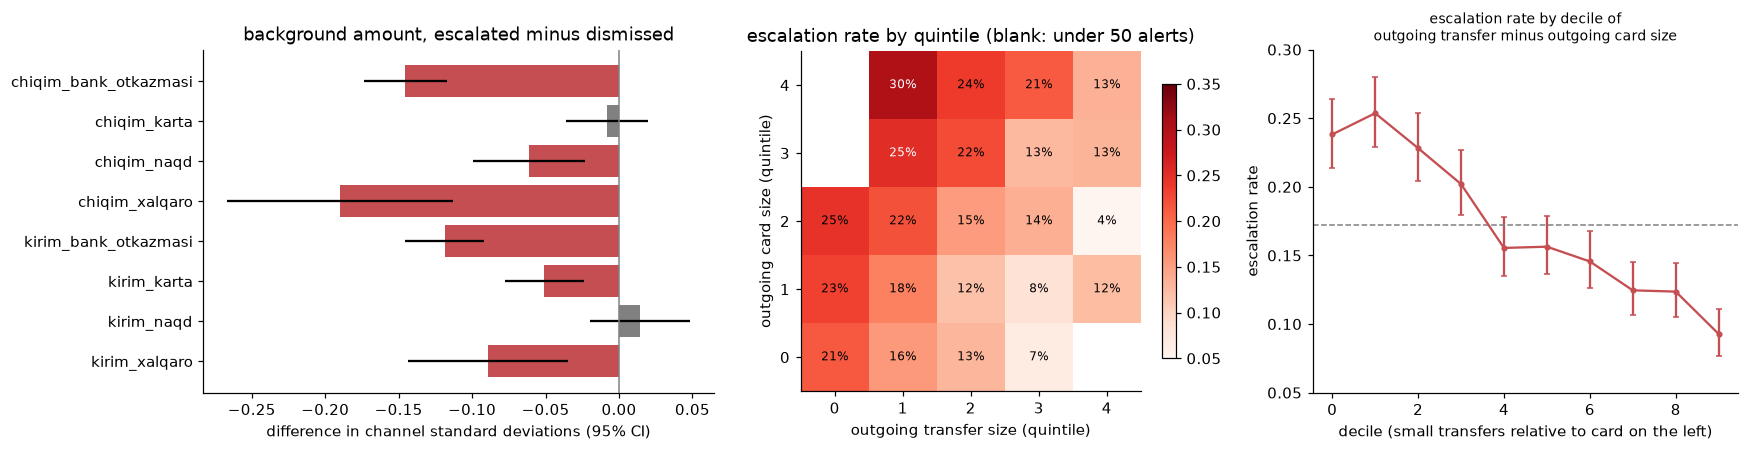

In [68]:
x_rel = relative["outgoing transfer minus outgoing card"]
grid = pd.DataFrame(
    {"card": pd.qcut(bg_z["chiqim_karta"], 5, labels=False), "transfer": pd.qcut(bg_z["chiqim_bank_otkazmasi"], 5, labels=False), "y": y_dev}
).dropna()
heat = grid.pivot_table(index="card", columns="transfer", values="y", aggfunc="mean")
heat_n = grid.pivot_table(index="card", columns="transfer", values="y", aggfunc="size")
heat = heat.where(heat_n >= 50)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), gridspec_kw={"width_ratios": [1.2, 1, 1]})
axes[0].barh(gap.index.astype(str), gap["escalated minus dismissed, channel sd"], xerr=gap["ci95"], color=[CLASS_COLORS[1] if abs(v) > c else "grey" for v, c in zip(gap["escalated minus dismissed, channel sd"], gap["ci95"])])
axes[0].axvline(0, c="grey", lw=1)
axes[0].invert_yaxis()
axes[0].set(title="background amount, escalated minus dismissed", xlabel="difference in channel standard deviations (95% CI)")
im = axes[1].imshow(heat, cmap="Reds", origin="lower", vmin=0.05, vmax=0.35)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        if heat.notna().iloc[i, j]:
            axes[1].text(j, i, f"{heat.iloc[i, j]:.0%}", ha="center", va="center", fontsize=8, color="white" if heat.iloc[i, j] > 0.25 else "black")
axes[1].set(title="escalation rate by quintile (blank: under 50 alerts)", xlabel="outgoing transfer size (quintile)", ylabel="outgoing card size (quintile)")
fig.colorbar(im, ax=axes[1], shrink=0.8)
ok = x_rel.notna().to_numpy()
plot_rate_by_bin(x_rel[ok], y_dev[ok], "escalation rate by decile of\noutgoing transfer minus outgoing card size", axes[2])
axes[2].set(xlabel="decile (small transfers relative to card on the left)", ylabel="escalation rate")
fig.tight_layout()
save_fig(
    fig,
    "F09_amounts_by_channel_and_class",
    "Escalated alerts make smaller bank transfers (outgoing -0.15, incoming -0.12 channel sd; AUC 0.426 and 0.439) at every lag, while card and cash barely differ. Against the alert's own card level the gap sharpens: escalation falls from about 24% to 9% across deciles of transfer-minus-card size (AUC 0.397).",
    "Main feature family: per-channel amount levels and cross-channel relative sizes (transfers against the alert's own card level).",
)

In [69]:
rate_by_bin(x_rel[ok], y_dev[ok])[["n", "x_med", "rate", "lo", "hi"]].round(3)

,n,x_med,rate,lo,hi
b,,,,,
0,1100,-0.781,0.238,0.214,0.264
1,1100,-0.526,0.254,0.229,0.280
2,1100,-0.400,0.228,0.204,0.254
3,1099,-0.296,0.202,0.179,0.227
4,1100,-0.204,0.155,0.135,0.178
5,1100,-0.117,0.156,0.136,0.179
6,1099,-0.025,0.146,0.126,0.168
7,1100,0.087,0.125,0.106,0.145
8,1100,0.237,0.124,0.105,0.144


In [70]:
pd.concat({"escalation rate": grid.pivot_table(index="card", columns="transfer", values="y", aggfunc="mean").round(3), "alerts": heat_n}, axis=1)

escalation rate                             alerts                     
transfer             0.0    1.0    2.0    3.0    4.0    0.0  1.0  2.0  3.0   4.0
card                                                                            
0.0                0.214  0.156  0.130  0.068  0.059   1506  437  162   59    34
1.0                0.232  0.178  0.118  0.084  0.123    505  821  500  262   114
2.0                0.247  0.219  0.154  0.136  0.042    146  584  683  523   265
3.0                0.194  0.252  0.224  0.127  0.131     36  290  572  723   579
4.0                0.385  0.301  0.239  0.213  0.134     13   73  285  635  1191

The heatmap shows the interaction behind it. Within the middle card quintile, escalation falls from 25% for the smallest transfers to 4% for the largest (146 and 265 alerts), and for mid-sized transfers it rises from 13% with the smallest card payments to 24% with the largest. Cells with fewer than 50 alerts are left blank, because the two sizes are correlated and the off-diagonal corners are thin. The relative measure turns this into a clear gradient: from about 24% escalated in the lowest three deciles to 9.3% in the highest, about 2.5 times apart. Escalated alerts move money by bank transfer in smaller amounts than their own card spending would suggest. The pattern recalls structuring, although the data cannot say why analysts escalate it.

### What the behavioural EDA changes

About 120 variables were compared in this section. At the single-test band about six would pass by chance, so the decisions rest on effects that are large relative to that band or that repeat across views.

| Hypothesis | Evidence on the development set | For the features |
|---|---|---|
| The trigger burst, and above all its change from the background, drives escalation | 13 trigger variables at AUC 0.470 to 0.528, trigger rate ratio 0.494; together CV AUC 0.547 | Not supported on its own. A compact trigger family is tested, at low priority |
| Escalated alerts build up activity before the alert | Same curve shape, a steady 5% level gap, no build-up | Background counts as a level; 7, 30 and 90-day windows only as defaults |
| Faster or more concentrated bursts | AUC 0.480 to 0.514 | Low priority |
| Pass-through and outgoing direction | Trigger outgoing share 0.528, outflows within 24 h of an inflow 0.526 | A small typology family |
| Channel mix and transaction order | Shares 0.476 to 0.527, transitions within 0.03 of chance | Low priority |
| Amounts, channel-relative | Transfers −0.15 and −0.12 channel sd smaller at every lag; transfer minus card size 0.397, deciles from about 24% to 9% | Main family: per-channel amount levels and cross-channel relative sizes |
| Trigger boundary | Identical AUCs under `lag_days <= 1` and the last hour | `lag_days <= 1` for composition, the burst core for timing |

The behavioural picture differs from the one the audit suggested. The burst is what every alert has in common, not what sets escalated alerts apart. What sets them apart is a steady trait of the whole history: bank transfers that are small for the alert's own level of spending, with a little more activity and a slight lean towards pass-through.

## Exports

The figure findings and actions collected by `save_fig` go to the EDA website.

In [71]:
(ART_DIR / "insights.json").write_text(json.dumps(INSIGHTS, indent=2, ensure_ascii=False))
[i["figure"] for i in INSIGHTS]

['F00a_hour_weekday',
 'F00b_relative_time',
 'F00c_amount_index',
 'F01_target_and_monthly_rate',
 'F02_alerts_per_week_train_test',
 'F05_weekly_transactions_by_type',
 'F03_background_volume_by_class',
 'F06_background_activity_by_class',
 'F04_trigger_test_by_decile',
 'F10_burst_compression_by_class',
 'F07_incoming_outgoing_by_class',
 'F08_channel_mix_by_class',
 'F11_transition_lift',
 'F09_amounts_by_channel_and_class']